## Introduction

Weather is one of the most universal parts of everyday life, but it is not experienced in the same way everywhere. A typical day in Singapore may be consistently warm and humid, while a day in Moscow may depend strongly on the season, and a day in Dubai may be shaped more by dry heat than rainfall. Although people often describe cities using simple labels such as “hot,” “cold,” “wet,” or “humid,” these labels can hide important differences in how weather is actually experienced across time.

This project explores daily weather patterns across **50 major global cities** during **2025** using the **Global Daily Weather Data 2025** dataset from the **Open-Meteo Historical Weather API**. The dataset includes daily observations of temperature, precipitation, wind speed, and humidity for cities across the Americas, Europe, Asia, Africa, and Oceania. Because it covers a full year and a geographically diverse set of cities, it provides a useful opportunity to compare urban weather across different climate zones.

The motivation for this project is to move beyond simple city rankings based only on average temperature. Two cities may have similar annual averages but differ greatly in seasonality, rainfall concentration, humidity, or the frequency of extreme weather days. For example, a city with stable warmth throughout the year may feel very different from a city with large seasonal swings, even if their annual mean temperatures are similar. In the same way, hot weather in a dry city may be experienced differently from hot weather in a humid one. These differences make weather a strong topic for data storytelling because it combines familiar real-world relevance with rich opportunities for comparison, pattern detection, and visual communication.

The project is also motivated by the need to communicate weather patterns in a way that is accessible to a non-expert audience. Rather than presenting weather only as a set of raw measurements, the analysis aims to show how temperature, rainfall, humidity, wind, and extremes interact to create distinct “weather profiles” for different cities. By combining data wrangling, visualization, mapping, interactivity, and an NLP-style summary, the project tells a broader story about how geography shapes urban climate experience.

### Research Questions

This analysis is guided by one main research question and several supporting questions.

#### Main Research Question
**How do major global cities differ in their weather profiles across 2025, and what do temperature, rainfall, humidity, seasonality, and extreme events reveal about urban climate experience?**

#### Supporting Research Questions

1. **How wide is the overall range of daily weather conditions across the 50 cities?**  
   This helps establish the global spread of temperatures and other weather variables in the dataset.

2. **Which cities were hottest, coolest, wettest, most humid, or windiest on average in 2025?**  
   This allows comparison of annual average weather conditions across cities.

3. **How does seasonality differ across cities?**  
   This explores whether cities experience stable weather year-round or strong seasonal variation.

4. **Which cities show the greatest variability in temperature over time?**  
   This helps distinguish more stable climates from more volatile ones.

5. **How do rainfall and humidity combine to create different weather profiles, such as dry heat, humid heat, or wet tropical conditions?**  
   This moves beyond temperature alone and examines how multiple weather dimensions interact.

6. **Which cities experienced the highest number of extreme heat, heavy rain, or high wind days?**  
   This focuses on weather exposure and potential disruption rather than just average conditions.

7. **How are these patterns distributed geographically?**  
   This motivates the mapping component and helps connect weather differences to place.

8. **How can structured weather data be translated into more human-readable descriptions?**  
   This motivates the NLP-style visualization, which turns numerical weather conditions into descriptive text such as “hot,” “humid,” or “rainy.”

Overall, the goal of this project is not only to compare cities, but to explain how different dimensions of weather combine to shape the lived climate experience of urban environments around the world.

## Data Description

This project uses the **Global Daily Weather Data 2025** dataset, a city-level daily weather dataset covering **50 major cities** from **2025-01-01 to 2025-12-31**. Sourced from the **Open-Meteo Historical Weather API**, the dataset contains **18,250 observations**, where each row represents one city on one day.

The dataset includes a combination of:
- **location variables**: `city`, `country`, `latitude`, `longitude`
- **temperature measures**: `temp_max_c`, `temp_min_c`, `temp_mean_c`
- **atmospheric and precipitation measures**: `precipitation_mm`, `rain_mm`, `wind_max_kmh`, `humidity_pct`

One of the main strengths of this dataset is its **balanced and standardized structure**. Every city is observed at the same daily frequency across the full calendar year, which makes comparisons more consistent than datasets with irregular time coverage or missing periods. This allows the analysis to compare cities fairly across seasons, annual averages, and extreme events without needing to correct for unequal observation windows.

Another unique feature of the dataset is its **global breadth combined with urban focus**. Instead of looking at a single country or region, the dataset brings together cities from multiple continents within one unified format. At the same time, it remains focused on major urban locations, making it especially useful for comparing how weather is experienced in cities rather than in broad national or rural averages. This makes the dataset particularly suitable for a storytelling-based project centered on differences in urban climate experience.

A further strength is that the dataset includes multiple weather dimensions in the same table. Rather than limiting the analysis to temperature alone, it allows the project to examine how **heat, rainfall, humidity, and wind interact**. This makes it possible to identify richer weather profiles, such as cities that are hot but dry, warm but highly seasonal, or humid and rain-heavy throughout the year.

For this project, the raw data was further enriched with derived variables to support analysis and visualization. These include time-based features such as month and quarter, daily temperature range, and binary indicators for extreme heat, heavy rain, and high wind days. A continent label was also added through a lookup table to support regional comparisons and mapping.

## Data Dictionary

| Variable | Type | Unit | Definition | Transformation / Notes |
|---|---|---:|---|---|
| `date` | datetime | — | Calendar date of the observation | Converted from string to datetime format using `pd.to_datetime()` |
| `city` | categorical | — | Name of the city | Used as the primary city identifier |
| `country` | categorical | ISO country code | Country associated with the city | Used for grouping and country-level mapping |
| `latitude` | numeric | decimal degrees | Latitude of the city | Used for geospatial mapping and ML features |
| `longitude` | numeric | decimal degrees | Longitude of the city | Used for geospatial mapping and ML features |
| `temp_max_c` | numeric | °C | Maximum daily temperature | Used to define `extreme_heat_day` |
| `temp_min_c` | numeric | °C | Minimum daily temperature | Used in ML model and daily range calculation |
| `temp_mean_c` | numeric | °C | Mean daily temperature | Main measure for temperature comparisons and trends |
| `precipitation_mm` | numeric | mm | Total daily precipitation | Used to define `heavy_rain_day` and annual rainfall totals |
| `rain_mm` | numeric | mm | Daily rainfall only | Used as a separate precipitation-related feature |
| `wind_max_kmh` | numeric | km/h | Maximum daily wind speed | Used to define `high_wind_day` |
| `humidity_pct` | numeric | % | Mean daily relative humidity | Used to compare humidity burden across cities |
| `month` | numeric | 1–12 | Month extracted from `date` | Created for seasonal and monthly trend analysis |
| `month_name` | categorical | — | Abbreviated month name (e.g., Jan, Feb) | Created for labeling plots |
| `quarter` | numeric | 1–4 | Quarter extracted from `date` | Created for time-based grouping |
| `day_of_year` | numeric | 1–365 | Day number within the year | Created for time series analysis |
| `temp_range_c` | numeric | °C | Difference between daily max and min temperature | Calculated as `temp_max_c - temp_min_c` |
| `extreme_heat_day` | binary | 0/1 | Indicator for very hot days | Created as `1` if `temp_max_c > 35`, else `0` |
| `heavy_rain_day` | binary | 0/1 | Indicator for heavy precipitation days | Created as `1` if `precipitation_mm > 20`, else `0` |
| `high_wind_day` | binary | 0/1 | Indicator for high wind days | Created as `1` if `wind_max_kmh > 40`, else `0` |
| `continent` | categorical | — | Continent of the city | Added through a manual lookup table and merge |
| `weather_text` *(optional NLP feature)* | text | — | Derived short text description of daily weather | Created from weather thresholds, e.g. “hot humid rainy” |

## Derived Variables Used in This Project

To support the analysis, several variables were engineered from the raw data:

- **Time features**
  - `month`
  - `month_name`
  - `quarter`
  - `day_of_year`

- **Weather variability**
  - `temp_range_c = temp_max_c - temp_min_c`

- **Extreme event indicators**
  - `extreme_heat_day = 1` if `temp_max_c > 35`
  - `heavy_rain_day = 1` if `precipitation_mm > 20`
  - `high_wind_day = 1` if `wind_max_kmh > 40`

- **Geographic grouping**
  - `continent`, added through a city-to-continent lookup table

- **Optional NLP-style feature**
  - `weather_text`, a derived text label summarizing each day’s conditions using words such as `"very_hot"`, `"humid"`, `"rainy"`, `"windy"`, or `"stable"`

## Notes on Units and Interpretation

- Temperatures are recorded in **degrees Celsius (°C)**.
- Precipitation and rainfall are recorded in **millimeters (mm)**.
- Wind speed is recorded in **kilometers per hour (km/h)**.
- Humidity is recorded as **relative humidity (%)**.
- Extreme thresholds were chosen to create interpretable indicators for storytelling and comparison, but they are somewhat subjective and should be interpreted as analytical definitions rather than universal climate standards.


## Setup

The analysis uses Python libraries for data wrangling, visualization, mapping, and machine learning. A fixed random seed (`42`) is set to ensure reproducibility of results.

In [1]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Mapping
import geopandas as gpd
import folium

# ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, classification_report
)

# Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Settings
SEED = 42
np.random.seed(SEED)

## Loading and Inspecting the Data

The dataset is first loaded into Python using `pandas`, then inspected to understand its structure, data types, and overall summary statistics. This step helps confirm that the data has been imported correctly before cleaning and analysis begin.

In [2]:
weather = pd.read_csv("Data/global_daily_weather_2025.csv")

display(weather.head())
display(weather.info())
display(weather.describe(include='all'))

,date,city,country,latitude,longitude,temp_max_c,temp_min_c,temp_mean_c,precipitation_mm,rain_mm,wind_max_kmh,humidity_pct
0,2025-01-01,New York,US,40.71,-74.01,10.9,3.9,7.4,4.5,4.5,23.2,81
1,2025-01-02,New York,US,40.71,-74.01,5.4,0.3,2.6,0.0,0.0,25.1,56
2,2025-01-03,New York,US,40.71,-74.01,3.2,-1.9,0.4,0.0,0.0,17.1,59
3,2025-01-04,New York,US,40.71,-74.01,-0.1,-2.7,-1.4,0.0,0.0,26.1,51
4,2025-01-05,New York,US,40.71,-74.01,0.3,-3.6,-2.2,0.0,0.0,19.9,52


<class 'pandas.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              18250 non-null  str    
 1   city              18250 non-null  str    
 2   country           18250 non-null  str    
 3   latitude          18250 non-null  float64
 4   longitude         18250 non-null  float64
 5   temp_max_c        18250 non-null  float64
 6   temp_min_c        18250 non-null  float64
 7   temp_mean_c       18250 non-null  float64
 8   precipitation_mm  18250 non-null  float64
 9   rain_mm           18250 non-null  float64
 10  wind_max_kmh      18250 non-null  float64
 11  humidity_pct      18250 non-null  int64  
dtypes: float64(8), int64(1), str(3)
memory usage: 2.0 MB


None

,date,city,country,latitude,longitude,temp_max_c,temp_min_c,temp_mean_c,precipitation_mm,rain_mm,wind_max_kmh,humidity_pct
count,18250,18250,18250,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000
unique,365,50,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2025-01-01,New York,US,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,50,365,1825,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,24.382000,21.222000,22.245518,14.028723,17.842619,2.950329,2.889156,14.733616,70.250027
std,NaN,NaN,NaN,27.643681,72.154808,9.875310,8.988823,9.203385,6.862478,6.838995,5.597701,16.819765
min,NaN,NaN,NaN,-37.810000,-118.240000,-15.400000,-21.900000,-18.400000,0.000000,0.000000,1.700000,6.000000
25%,NaN,NaN,NaN,6.520000,-9.140000,15.900000,8.100000,12.000000,0.000000,0.000000,10.900000,62.000000
50%,NaN,NaN,NaN,31.660000,18.245000,23.200000,14.400000,18.500000,0.100000,0.100000,13.800000,74.000000
75%,NaN,NaN,NaN,43.650000,77.210000,30.200000,22.300000,26.000000,2.600000,2.400000,17.600000,83.000000


## Feature Engineering

To prepare the dataset for analysis, the `date` column is converted into datetime format and used to extract useful time-based features such as month, quarter, and day of year. Additional variables are then created to support the analysis, including daily temperature range and binary indicators for extreme heat, heavy rain, and high wind days. These derived features make it easier to study seasonality, variability, and weather extremes across cities.

In [3]:
# Parse date
weather["date"] = pd.to_datetime(weather["date"])

# Time features
weather["month"] = weather["date"].dt.month
weather["month_name"] = weather["date"].dt.strftime("%b")
weather["quarter"] = weather["date"].dt.quarter
weather["day_of_year"] = weather["date"].dt.dayofyear

# Derived weather feature
weather["temp_range_c"] = weather["temp_max_c"] - weather["temp_min_c"]

# Extreme event indicators
weather["extreme_heat_day"] = (weather["temp_max_c"] > 35).astype(int)
weather["heavy_rain_day"] = (weather["precipitation_mm"] > 20).astype(int)
weather["high_wind_day"] = (weather["wind_max_kmh"] > 40).astype(int)

display(weather.head())
display(weather.info())
display(weather.describe(include='all'))

,date,city,country,latitude,longitude,temp_max_c,temp_min_c,temp_mean_c,precipitation_mm,rain_mm,wind_max_kmh,humidity_pct,month,month_name,quarter,day_of_year,temp_range_c,extreme_heat_day,heavy_rain_day,high_wind_day
0,2025-01-01,New York,US,40.71,-74.01,10.9,3.9,7.4,4.5,4.5,23.2,81,1,Jan,1,1,7.0,0,0,0
1,2025-01-02,New York,US,40.71,-74.01,5.4,0.3,2.6,0.0,0.0,25.1,56,1,Jan,1,2,5.1,0,0,0
2,2025-01-03,New York,US,40.71,-74.01,3.2,-1.9,0.4,0.0,0.0,17.1,59,1,Jan,1,3,5.1,0,0,0
3,2025-01-04,New York,US,40.71,-74.01,-0.1,-2.7,-1.4,0.0,0.0,26.1,51,1,Jan,1,4,2.6,0,0,0
4,2025-01-05,New York,US,40.71,-74.01,0.3,-3.6,-2.2,0.0,0.0,19.9,52,1,Jan,1,5,3.9,0,0,0


<class 'pandas.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              18250 non-null  datetime64[us]
 1   city              18250 non-null  str           
 2   country           18250 non-null  str           
 3   latitude          18250 non-null  float64       
 4   longitude         18250 non-null  float64       
 5   temp_max_c        18250 non-null  float64       
 6   temp_min_c        18250 non-null  float64       
 7   temp_mean_c       18250 non-null  float64       
 8   precipitation_mm  18250 non-null  float64       
 9   rain_mm           18250 non-null  float64       
 10  wind_max_kmh      18250 non-null  float64       
 11  humidity_pct      18250 non-null  int64         
 12  month             18250 non-null  int32         
 13  month_name        18250 non-null  str           
 14  quarter           18250 non-null 

None

,date,city,country,latitude,longitude,temp_max_c,temp_min_c,temp_mean_c,precipitation_mm,rain_mm,wind_max_kmh,humidity_pct,month,month_name,quarter,day_of_year,temp_range_c,extreme_heat_day,heavy_rain_day,high_wind_day
count,18250,18250,18250,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000
unique,NaN,50,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,New York,US,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jan,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,365,1825,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1550,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025-07-02 00:00:00,NaN,NaN,24.382000,21.222000,22.245518,14.028723,17.842619,2.950329,2.889156,14.733616,70.250027,6.526027,NaN,2.509589,183.000000,8.216795,0.058740,0.031397,0.001205
min,2025-01-01 00:00:00,NaN,NaN,-37.810000,-118.240000,-15.400000,-21.900000,-18.400000,0.000000,0.000000,1.700000,6.000000,1.000000,NaN,1.000000,1.000000,0.500000,0.000000,0.000000,0.000000
25%,2025-04-02 00:00:00,NaN,NaN,6.520000,-9.140000,15.900000,8.100000,12.000000,0.000000,0.000000,10.900000,62.000000,4.000000,NaN,2.000000,92.000000,5.600000,0.000000,0.000000,0.000000
50%,2025-07-02 00:00:00,NaN,NaN,31.660000,18.245000,23.200000,14.400000,18.500000,0.100000,0.100000,13.800000,74.000000,7.000000,NaN,3.000000,183.000000,7.900000,0.000000,0.000000,0.000000
75%,2025-10-01 00:00:00,NaN,NaN,43.650000,77.210000,30.200000,22.300000,26.000000,2.600000,2.400000,17.600000,83.000000,10.000000,NaN,4.000000,274.000000,10.600000,0.000000,0.000000,0.000000
max,2025-12-31 00:00:00,NaN,NaN,60.170000,151.210000,46.500000,36.800000,40.400000,136.500000,136.500000,60.600000,99.000000,12.000000,NaN,4.000000,365.000000,23.300000,1.000000,1.000000,1.000000


## Adding Geographic Context

To support regional comparisons, a continent label is added to each city using a lookup table and a merge operation. This step enriches the dataset with broader geographic context, making it possible to compare weather patterns not only by city, but also across continents.

In [4]:
continent_lookup = pd.DataFrame({
    "city": [
        "New York", "Los Angeles", "Chicago", "Houston", "Miami", "Toronto",
        "Mexico City", "Sao Paulo", "Buenos Aires", "Santiago", "Lima", "Bogota",
        "London", "Paris", "Berlin", "Madrid", "Rome", "Moscow", "Stockholm",
        "Oslo", "Amsterdam", "Zurich", "Vienna", "Warsaw", "Lisbon", "Athens",
        "Dublin", "Helsinki", "Istanbul",
        "Tokyo", "Seoul", "Beijing", "Shanghai", "Mumbai", "Delhi", "Bangkok",
        "Singapore", "Jakarta", "Manila", "Ho Chi Minh City", "Kuala Lumpur",
        "Dubai", "Riyadh", "Tel Aviv",
        "Cairo", "Lagos", "Nairobi", "Cape Town",
        "Sydney", "Melbourne"
    ],
    "continent": [
        "Americas","Americas","Americas","Americas","Americas","Americas",
        "Americas","Americas","Americas","Americas","Americas","Americas",
        "Europe","Europe","Europe","Europe","Europe","Europe","Europe",
        "Europe","Europe","Europe","Europe","Europe","Europe","Europe",
        "Europe","Europe","Europe",
        "Asia","Asia","Asia","Asia","Asia","Asia","Asia",
        "Asia","Asia","Asia","Asia","Asia",
        "Asia","Asia","Asia",
        "Africa","Africa","Africa","Africa",
        "Oceania","Oceania"
    ]
})

weather = weather.merge(continent_lookup, on="city", how="left")

weather[["city", "continent"]].drop_duplicates().sort_values(["continent", "city"]).head(20)

,city,continent
9125,Cairo,Africa
10220,Cape Town,Africa
9490,Lagos,Africa
9855,Nairobi,Africa
17155,Bogota,Americas
8760,Buenos Aires,Americas
730,Chicago,Americas
1095,Houston,Americas
16790,Lima,Americas
365,Los Angeles,Americas


## Creating Summary Tables for Analysis

To answer the research questions at different levels, the dataset is reorganized into several summary tables. Each table serves a different analytical purpose: some are designed for comparing cities overall, others for tracking seasonal patterns, supporting maps, or reshaping the data into forms better suited for specific visualizations. Together, these tables form the backbone of the analysis by making the raw daily observations easier to interpret and visualize.

### City-Level Annual Summary

This table summarizes the full year of weather for each city. It is created to support overall city-to-city comparisons across key dimensions such as average temperature, rainfall, humidity, wind, variability, and extreme weather exposure. By reducing the daily data into one row per city, this table makes it easier to identify broad weather profiles and rank cities by annual conditions.

In [5]:
city_summary = (
    weather.groupby(["city", "country", "continent"], as_index=False)
      .agg(
          avg_temp_mean=("temp_mean_c", "mean"),
          avg_temp_max=("temp_max_c", "mean"),
          avg_temp_min=("temp_min_c", "mean"),
          temp_std=("temp_mean_c", "std"),
          annual_temp_range=("temp_mean_c", lambda x: x.max() - x.min()),
          total_precipitation=("precipitation_mm", "sum"),
          total_rain=("rain_mm", "sum"),
          avg_humidity=("humidity_pct", "mean"),
          avg_wind=("wind_max_kmh", "mean"),
          extreme_heat_days=("extreme_heat_day", "sum"),
          heavy_rain_days=("heavy_rain_day", "sum"),
          high_wind_days=("high_wind_day", "sum")
      )
)

city_summary.head()

,city,country,continent,avg_temp_mean,avg_temp_max,avg_temp_min,temp_std,annual_temp_range,total_precipitation,total_rain,avg_humidity,avg_wind,extreme_heat_days,heavy_rain_days,high_wind_days
0,Amsterdam,NL,Europe,11.271507,14.718356,8.116438,6.007176,28.9,777.5,750.9,80.164384,16.313151,0,6,1
1,Athens,GR,Europe,18.916986,23.180548,15.066027,7.499080,31.3,565.9,565.9,59.536986,11.906027,24,7,0
2,Bangkok,TH,Asia,28.197534,32.475616,24.820822,1.555960,9.8,1675.3,1675.3,72.312329,11.154521,49,15,0
3,Beijing,CN,Asia,14.407671,19.116164,9.841644,11.293249,43.1,711.0,701.0,49.260274,12.907671,18,8,0
4,Berlin,DE,Europe,10.654521,14.641096,6.890685,7.456383,37.1,610.5,558.1,74.835616,15.498904,1,3,0


### City-Level Monthly Summary

This table aggregates weather data by city and month to capture seasonal patterns over time. It is created to support analyses of monthly temperature trends, rainfall seasonality, and changes in humidity or wind across the year. This structure is especially useful for line charts and other visuals that compare how cities evolve month by month.

In [6]:
monthly_summary = (
    weather.groupby(["city", "country", "continent", "month", "month_name"], as_index=False)
      .agg(
          monthly_avg_temp=("temp_mean_c", "mean"),
          monthly_precipitation=("precipitation_mm", "sum"),
          monthly_avg_humidity=("humidity_pct", "mean"),
          monthly_avg_wind=("wind_max_kmh", "mean")
      )
)

monthly_summary.head()

,city,country,continent,month,month_name,monthly_avg_temp,monthly_precipitation,monthly_avg_humidity,monthly_avg_wind
0,Amsterdam,NL,Europe,1,Jan,3.770968,91.8,88.161290,17.848387
1,Amsterdam,NL,Europe,2,Feb,3.782143,43.1,83.892857,15.289286
2,Amsterdam,NL,Europe,3,Mar,6.919355,8.7,78.354839,13.012903
3,Amsterdam,NL,Europe,4,Apr,10.893333,32.1,77.066667,12.976667
4,Amsterdam,NL,Europe,5,May,13.732258,51.2,70.774194,17.212903


### Country-Level Summary

This table aggregates the data at the country level to support geographic analysis and mapping. Since choropleth maps are typically drawn by country boundaries rather than city points, this summary provides country-level measures such as average temperature, total precipitation, humidity, and extreme heat days for use in map-based visualizations.

In [7]:
country_summary = (
    weather.groupby(["country"], as_index=False)
      .agg(
          country_avg_temp=("temp_mean_c", "mean"),
          country_total_precipitation=("precipitation_mm", "sum"),
          country_avg_humidity=("humidity_pct", "mean"),
          country_extreme_heat_days=("extreme_heat_day", "sum")
      )
)

country_summary.head()

,country,country_avg_temp,country_total_precipitation,country_avg_humidity,country_extreme_heat_days
0,AE,28.527123,37.1,55.912329,178
1,AR,18.351507,1233.4,68.591781,5
2,AT,11.504932,631.0,71.079452,3
3,AU,16.710685,2068.1,69.801370,17
4,BR,20.074521,1285.3,73.572603,0


### Pivot Table for Heatmap Visualization

This pivot table reshapes the monthly city summary into a matrix format, with cities as rows and months as columns. It is created specifically for heatmap-style visualizations, where color can be used to show how temperature changes across both cities and time. This makes seasonal patterns easier to compare at a glance.

In [8]:
temp_heatmap_data = (
    monthly_summary.pivot(index="city", columns="month", values="monthly_avg_temp")
)

temp_heatmap_data.head()

month,1,2,3,4,5,6,7,8,9,10,11,12
city,,,,,,,,,,,,
Amsterdam,3.770968,3.782143,6.919355,10.893333,13.732258,17.683333,18.670968,18.119355,15.156667,12.164516,7.753333,6.093548
Athens,10.883871,8.289286,13.729032,14.780000,20.667742,27.943333,30.596774,27.848387,24.733333,18.338710,16.706667,11.732258
Bangkok,27.393548,28.692857,30.170968,30.153333,28.635484,28.410000,27.835484,28.187097,27.410000,27.774194,26.066667,27.664516
Beijing,-0.967742,-0.007143,10.141935,17.340000,21.003226,27.886667,28.393548,26.187097,23.320000,12.629032,6.930000,-0.783871
Berlin,2.235484,0.610714,6.216129,11.960000,13.809677,19.696667,19.558065,18.851613,15.683333,10.251613,5.213333,3.116129


### Long-Format Table for Multi-Metric Comparison

This long-format table reshapes selected city-level metrics into a tidy structure with one metric per row. It is created to support flexible visualizations such as faceted charts or grouped comparisons across variables like average temperature, humidity, and wind. This format is useful when comparing multiple measures within the same plotting framework.

In [9]:
weather_long = city_summary.melt(
    id_vars=["city", "country", "continent"],
    value_vars=["avg_temp_mean", "avg_humidity", "avg_wind"],
    var_name="metric",
    value_name="value"
)

weather_long.head()

,city,country,continent,metric,value
0,Amsterdam,NL,Europe,avg_temp_mean,11.271507
1,Athens,GR,Europe,avg_temp_mean,18.916986
2,Bangkok,TH,Asia,avg_temp_mean,28.197534
3,Beijing,CN,Asia,avg_temp_mean,14.407671
4,Berlin,DE,Europe,avg_temp_mean,10.654521


## Exploring the Weather Story in the Data

With the dataset cleaned and the summary tables prepared, the next step is to move from data preparation to analysis. This section uses a sequence of visualizations to answer the project’s research questions and build a coherent story about how weather differs across global cities. Rather than looking at temperature, rainfall, humidity, or wind in isolation, the goal is to understand how these dimensions combine to shape different urban weather experiences.

The analysis begins with broad global patterns before moving into more specific comparisons of seasonality, variability, rainfall, humidity, and extreme conditions. This progression is intentional: it starts by establishing the overall range of weather captured in the dataset, then gradually narrows in on the factors that make one city’s climate feel different from another’s. Each section is therefore designed not just to present a plot, but to answer a specific question and contribute to the larger narrative of the project.

### How broad is the range of daily temperature conditions across global cities?

Before comparing individual cities, it is important to first understand the overall spread of temperature conditions represented in the dataset. Since this project aims to compare urban weather experiences across the world, the first step is to examine whether the data captures a narrow band of similar climates or a wide spectrum of daily temperature environments. To do this, I look at the distribution of daily mean temperatures across all city-day observations in 2025. This provides a high-level view of the temperature range covered in the dataset and helps establish the climatic diversity of the cities included.

The distribution shows that the dataset spans a very wide range of daily mean temperatures, from below **-10°C** on the cold end to close to **40°C** on the hot end. Most observations are concentrated between roughly **10°C and 30°C**, indicating that the majority of city-days fall within mild to warm conditions rather than extreme cold. At the same time, the long spread toward both lower and higher temperatures confirms that the dataset includes cities with very different climate realities.

Another notable feature is that the distribution is not perfectly symmetric. There appears to be a stronger concentration of observations in the warmer range, especially in the high teens to upper twenties, which suggests that many of the selected cities experience generally warm conditions for much of the year. There also seems to be more than one area of concentration, hinting that the dataset may contain distinct groups of cities, such as cooler seasonal cities and warmer tropical or subtropical cities.

Overall, this first view confirms that the dataset is well suited for a comparative global weather analysis. Rather than reflecting one common climate pattern, it captures substantial diversity in daily temperature conditions, which supports the broader goal of identifying different urban weather profiles across the 50 cities.

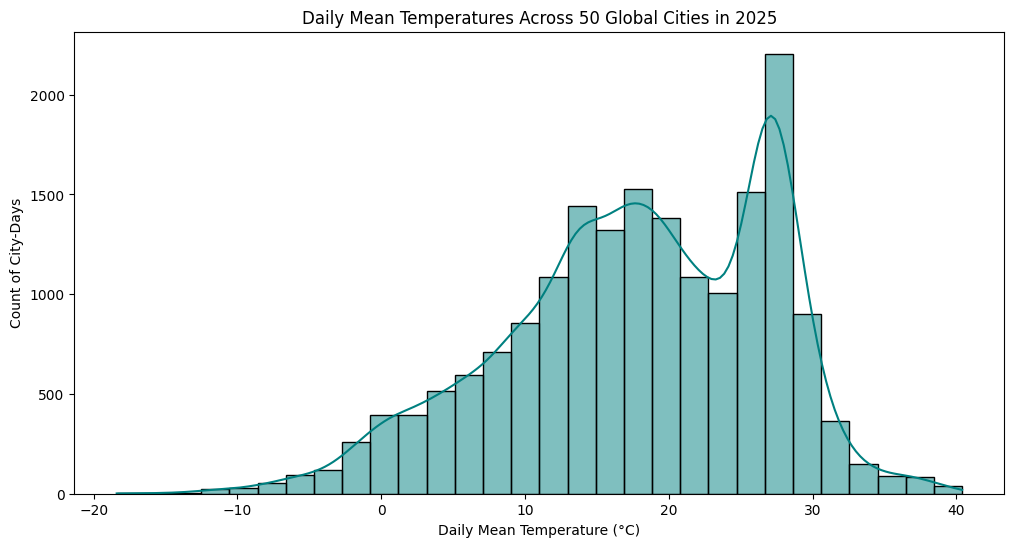

In [10]:
plt.figure(figsize=(12, 6))
sns.histplot(data=weather, x="temp_mean_c", bins=30, kde=True, color="teal")
plt.title("Daily Mean Temperatures Across 50 Global Cities in 2025")
plt.xlabel("Daily Mean Temperature (°C)")
plt.ylabel("Count of City-Days")
plt.show()

### Which cities were warmest and coolest on average in 2025?

After establishing the overall range of daily temperatures in the dataset, the next step is to compare cities based on their annual average conditions. This helps answer a more concrete research question: which cities were generally warmer or cooler across the year? To do this, I use the city-level summary table and rank cities by their average mean temperature. Coloring the cities by continent also helps reveal whether regional patterns appear in the ranking.

The results show a clear temperature gradient across the 50 cities. At the cooler end of the ranking are cities such as **Helsinki, Moscow, Stockholm, and Oslo**, all of which are located in higher-latitude parts of Europe. **Toronto** and **Chicago** also appear relatively cool, reinforcing the role of latitude and continental climate in shaping average temperature. In contrast, the warmest cities are concentrated largely in **Asia**, especially **Dubai, Bangkok, Riyadh, Manila, Kuala Lumpur, Ho Chi Minh City, Jakarta, and Mumbai**, all of which record annual average temperatures close to or above the upper twenties in degrees Celsius.

The chart also shows that warm cities are not limited to one single region. **Lagos, Singapore, Delhi, Miami, and Cairo** also appear near the top of the ranking, suggesting that tropical, subtropical, and desert climates all contribute to high annual temperatures, though likely in different ways. This is important because it shows that a high annual average does not necessarily imply the same type of weather experience. For example, the heat of **Dubai** is likely very different from the heat of **Singapore** or **Manila**, especially once humidity and rainfall are considered.

Another notable pattern is that European cities dominate much of the cooler half of the ranking, while Asian cities dominate much of the warmer half. This continental clustering suggests that geography plays a strong role in shaping annual temperature patterns. However, the ranking also includes cities from the Americas, Africa, and Oceania spread across the middle and upper ranges, indicating that global urban climates are diverse rather than neatly separated by continent alone.

Overall, this comparison provides a useful first ranking of city climates, but it also highlights a key limitation of averages: they summarize how warm a city is on average, but not how that warmth is distributed across the year. A city with a moderate annual average may still experience large seasonal swings, while another city with a similar average may remain stable year-round. This leads naturally to the next part of the analysis, which examines seasonality and variability in more detail.

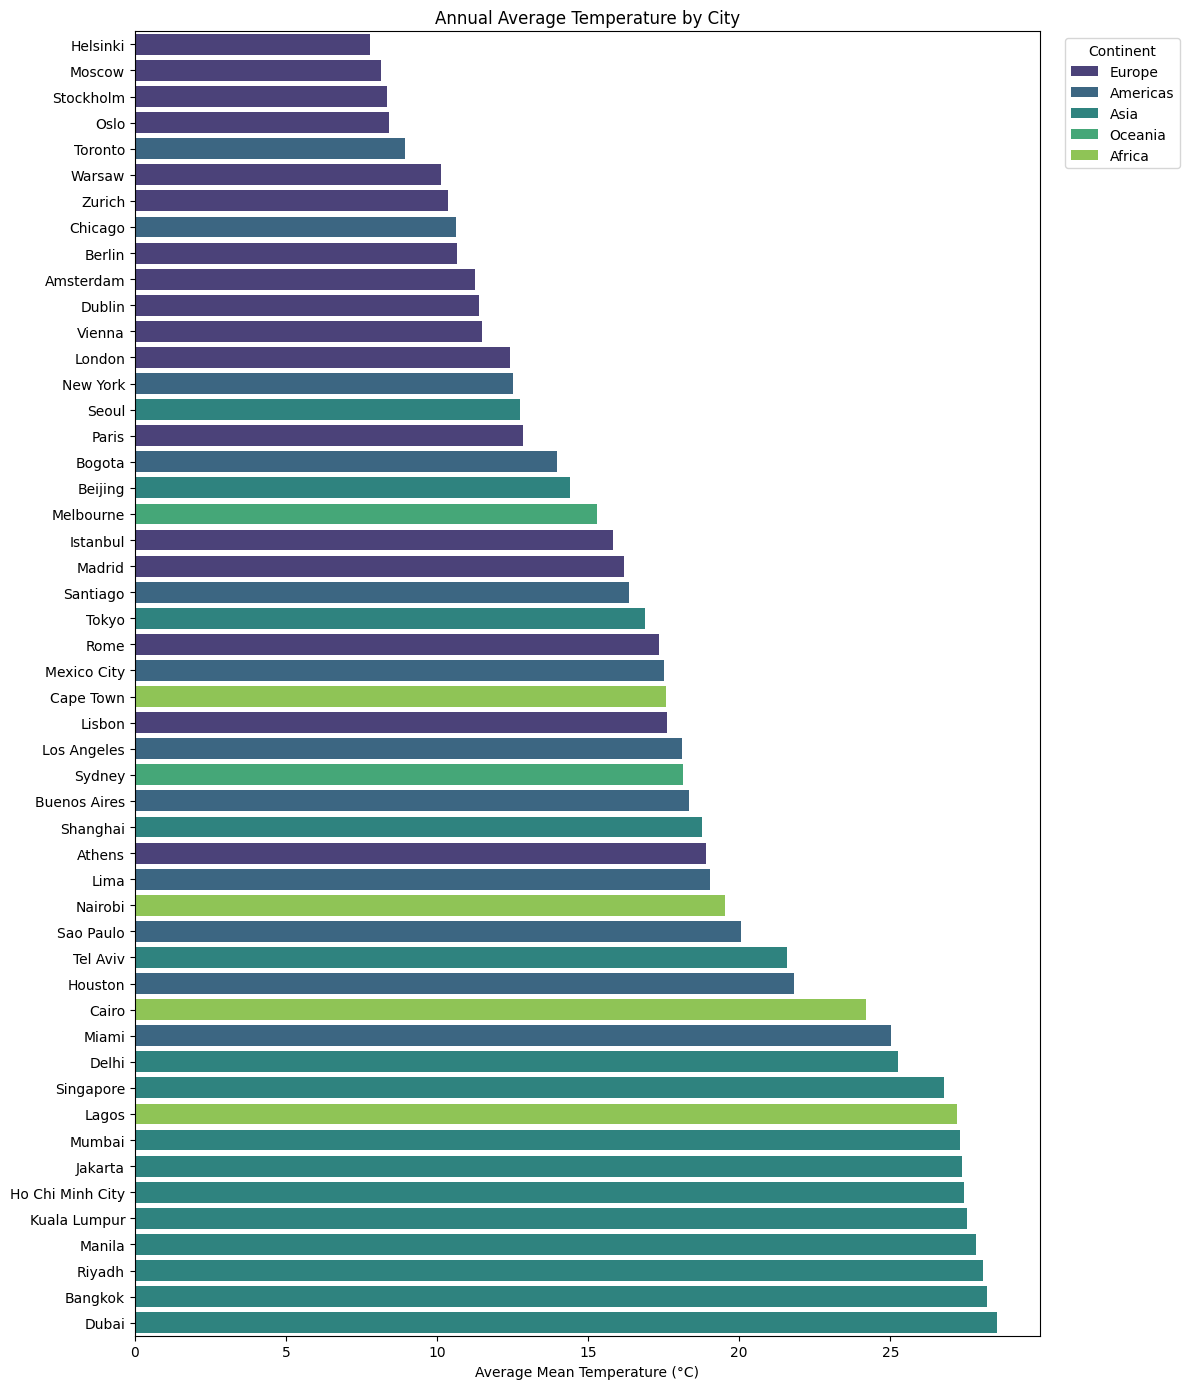

In [11]:
city_temp_rank = city_summary.sort_values("avg_temp_mean", ascending=True)

plt.figure(figsize=(12, 14))
sns.barplot(data=city_temp_rank, x="avg_temp_mean", y="city", hue="continent", dodge=False, palette="viridis")
plt.title("Annual Average Temperature by City")
plt.xlabel("Average Mean Temperature (°C)")
plt.ylabel("")
plt.legend(title="Continent", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Do cities with similar averages actually feel the same across the year?

Annual averages are useful, but they can hide an important part of climate experience: **seasonality**. Two cities may end the year with similar average temperatures while feeling completely different from month to month. To address this, I compare monthly average temperatures for a selected set of cities chosen to represent different climate types and world regions, including tropical, desert, temperate, continental, and Southern Hemisphere cities. This helps reveal whether warmth is steady throughout the year or produced by sharp seasonal swings.

The patterns show that cities differ not only in how warm they are, but in how their temperatures change over time. **Singapore** stands out as the most stable city in the comparison, remaining close to the high twenties throughout the year with only very small month-to-month variation. **Mumbai** is also consistently warm, though it shows a slightly more noticeable rise and fall across the year. These cities illustrate a tropical pattern in which weather is persistently warm rather than strongly seasonal.

By contrast, **Moscow**, **New York**, and **London** display much stronger seasonal variation. **Moscow** shows the most dramatic swing, moving from below freezing in the early and late parts of the year to above 20°C in summer. **New York** follows a similar but slightly less extreme pattern, while **London** also warms and cools over the year but remains more moderate overall. These cities show that a single annual average can mask very different seasonal realities, especially in continental and temperate climates.

**Dubai** presents a different kind of pattern: it is warm all year, but unlike Singapore, it rises sharply into extremely hot summer months before cooling again. This suggests that high annual average temperature can come from persistent warmth, as in Singapore, or from a combination of warm winters and extremely hot summers, as in Dubai. **Tokyo** also shows clear seasonality, but with milder winter temperatures than Moscow or New York and a strong summer peak. Meanwhile, **Sydney** provides an important Southern Hemisphere contrast, with its warmest months appearing at the beginning and end of the calendar year and its coolest period occurring mid-year.

Overall, this comparison shows that cities with similar annual averages may still offer very different lived weather experiences. Some are stable and consistently warm, some are sharply seasonal, and some reverse the usual yearly pattern due to their hemisphere. This reinforces the project’s central argument that average temperature alone is not enough to describe urban climate experience.

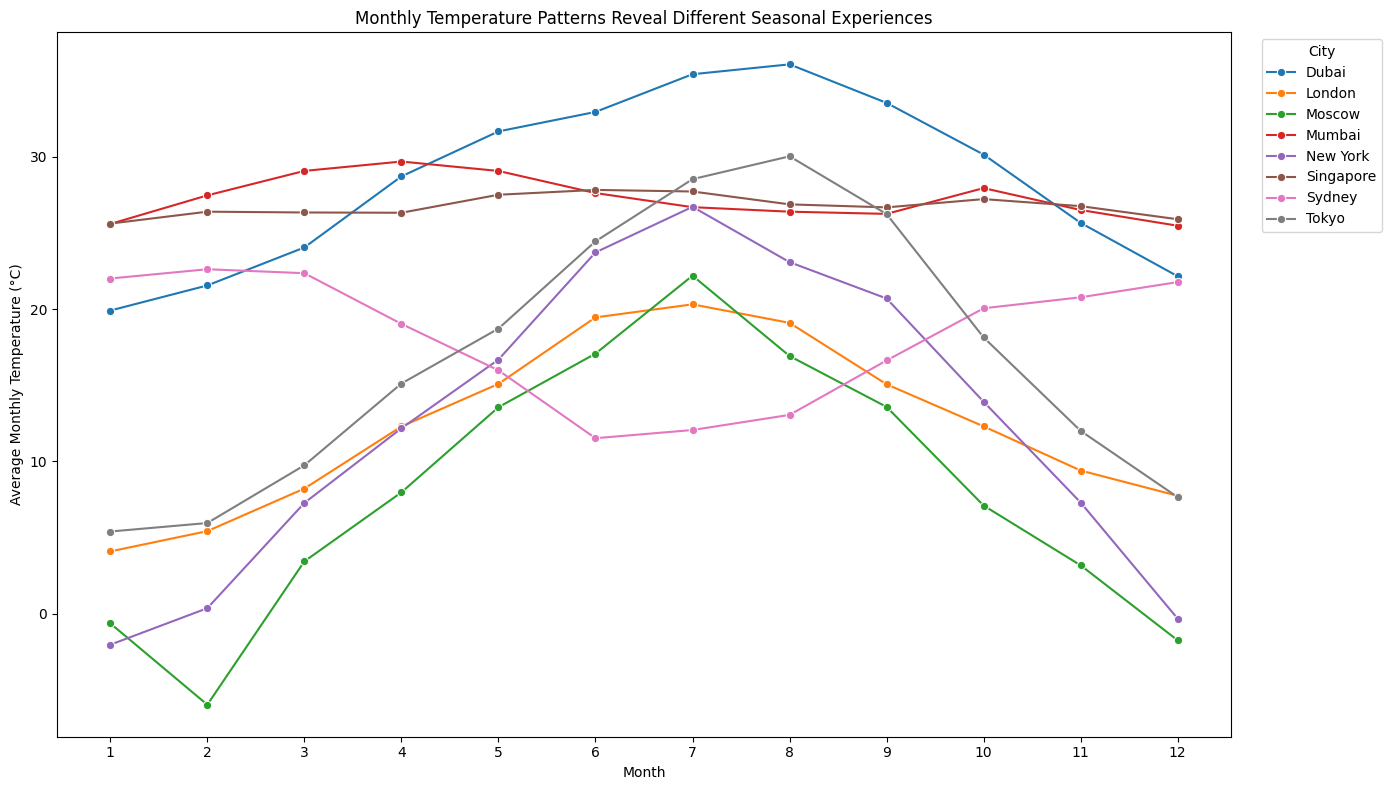

In [12]:
selected_cities = ["Singapore", "Dubai", "London", "Moscow", "New York", "Sydney", "Mumbai", "Tokyo"]

plot_data = monthly_summary[monthly_summary["city"].isin(selected_cities)].copy()
plot_data = plot_data.sort_values(["city", "month"])

plt.figure(figsize=(14, 8))
sns.lineplot(data=plot_data, x="month", y="monthly_avg_temp", hue="city", marker="o")
plt.title("Monthly Temperature Patterns Reveal Different Seasonal Experiences")
plt.xlabel("Month")
plt.ylabel("Average Monthly Temperature (°C)")
plt.xticks(range(1, 13))
plt.legend(title="City", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Which cities experience the most stable weather, and which face the greatest temperature swings?

Annual and monthly averages help summarize climate, but they still do not fully capture how predictable or variable a city’s weather feels from day to day. To answer this question, I compare the distribution of daily mean temperatures for each city and order the cities by their temperature variability. This approach makes it possible to see not only the typical temperature level in each city, but also how widely temperatures fluctuate over the course of the year.

The results show a strong contrast between highly seasonal cities and more stable tropical cities. Cities such as **Beijing, Chicago, Seoul, Toronto, New York, and Moscow** appear near the top of the variability ranking, with wide spreads and long whiskers. This indicates that these cities experience large temperature swings across the year, which is consistent with continental and temperate climates that move through distinct seasons. In these places, the lived weather experience changes substantially over time, from very cold periods to much warmer ones.

In contrast, cities such as **Singapore, Jakarta, Ho Chi Minh City, Lagos, Kuala Lumpur, and Manila** show much narrower distributions. Their boxplots are compact and concentrated within a relatively small temperature range, suggesting that temperatures remain fairly stable throughout the year. This pattern is characteristic of many tropical cities, where average warmth persists with much less seasonal variation. **Bogota** is also notable for its especially tight range, though at a cooler temperature level than the tropical Southeast Asian cities, showing that stability does not always mean heat.

Several cities occupy a middle ground. For example, **Dubai** has a relatively high temperature level overall but still shows a noticeable spread, reflecting hot conditions year-round with intensified summer heat. **Sydney**, **Los Angeles**, and **Cape Town** appear more moderate in both average temperature and variability, suggesting climates that are neither highly seasonal nor completely stable. These cities help illustrate that weather experience exists on a spectrum rather than in simple categories.

Overall, this comparison reinforces one of the central arguments of the project: cities with similar annual averages may still feel very different depending on how much temperatures fluctuate. Variability matters because it shapes how predictable a city’s climate is and how dramatically conditions change over the year. In that sense, stability versus volatility is an important part of a city’s weather identity, not just a secondary detail.

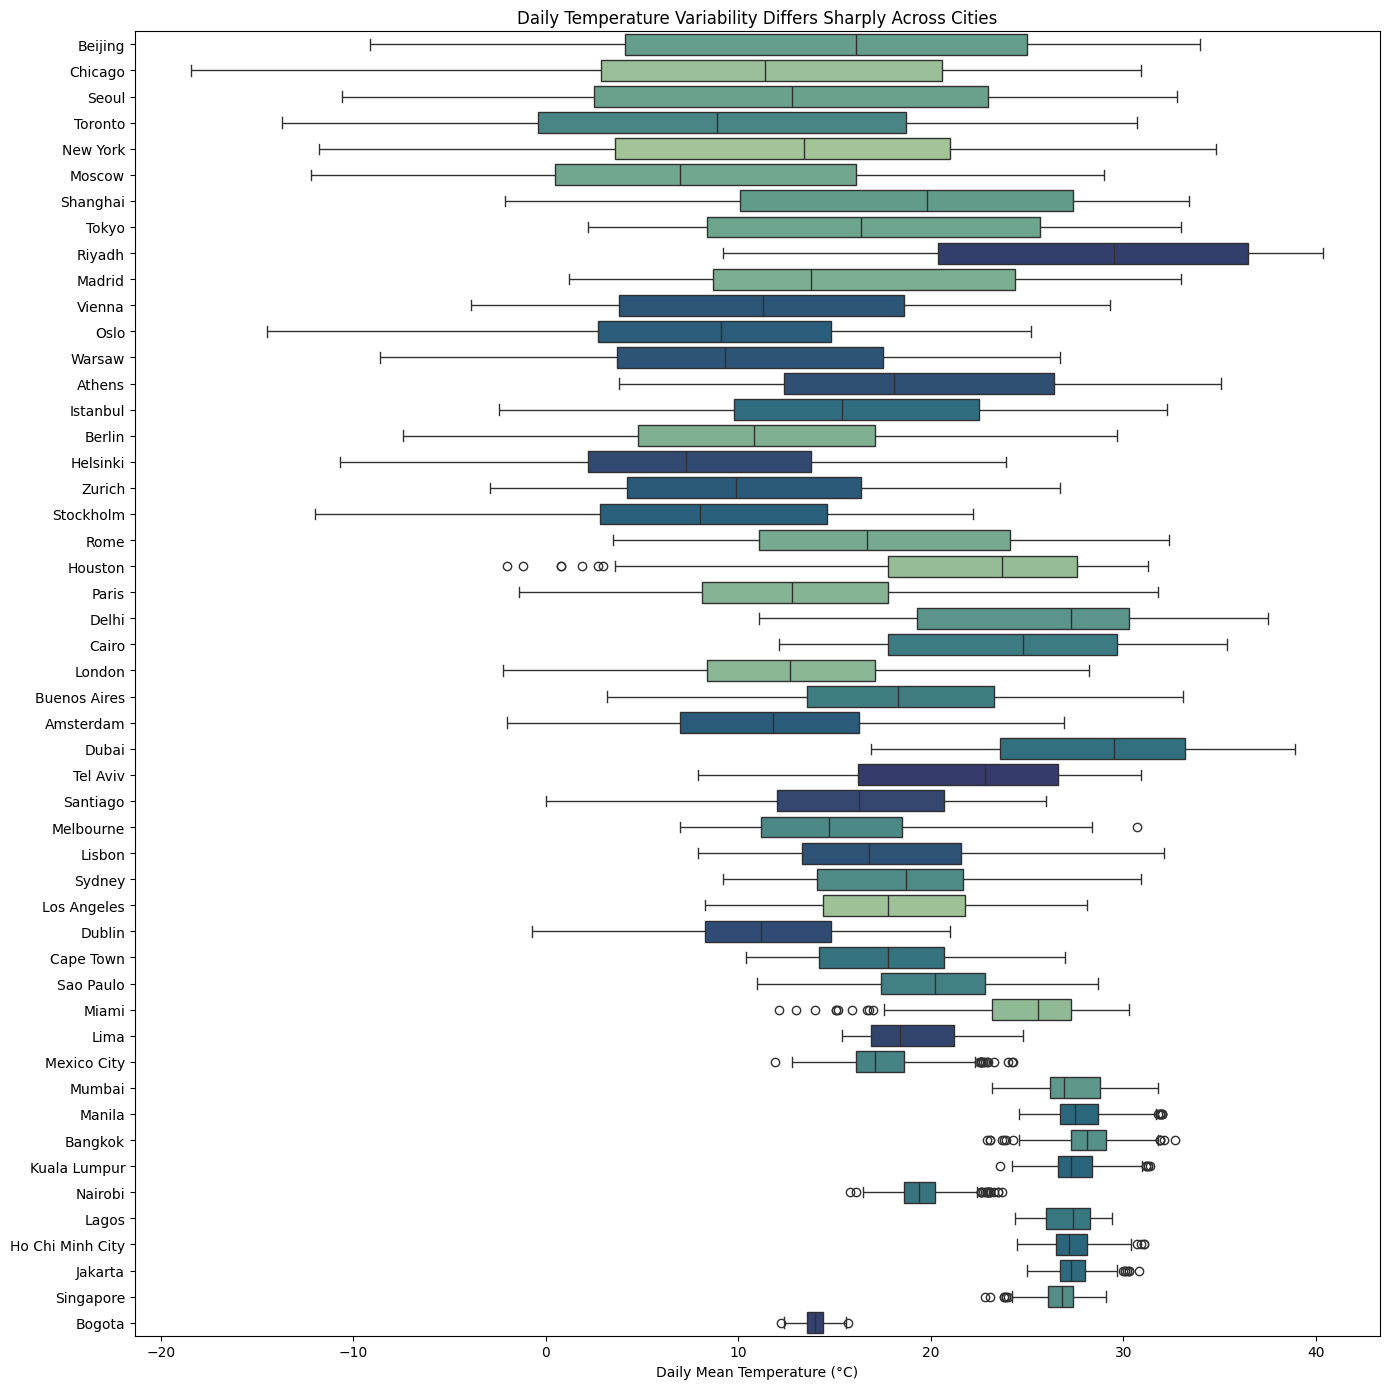

In [13]:
city_order = city_summary.sort_values("temp_std", ascending=False)["city"]

plt.figure(figsize=(14, 14))

sns.boxplot(
    data=weather,
    x="temp_mean_c",
    y="city",
    order=city_order,
    hue="city",
    palette="crest",
    legend=False
)

plt.title("Daily Temperature Variability Differs Sharply Across Cities")
plt.xlabel("Daily Mean Temperature (°C)")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Which cities were the wettest and driest in 2025?

Temperature explains only one part of weather experience. To understand how different cities actually feel and function, it is also important to compare how much precipitation they receive over the year. This section examines total annual precipitation by city in order to identify which places were especially dry, which were consistently wet, and whether rainfall is spread evenly across cities or concentrated in a smaller group. The cities are again colored by continent to help reveal broader regional patterns.

The results show that precipitation is much more unevenly distributed than temperature. A relatively small group of cities stands out as exceptionally wet, led by **Singapore**, **Jakarta**, **Kuala Lumpur**, **Mumbai**, and **Ho Chi Minh City**, all of which record annual rainfall totals well above most other cities in the dataset. **Manila** and **Bangkok** also appear near the top, reinforcing the idea that many of the wettest cities are concentrated in **Asia**, particularly in tropical and monsoon-influenced regions. This suggests that high rainfall is not a general feature of all warm cities, but is instead concentrated in specific climate zones.

At the opposite end of the ranking, cities such as **Cairo**, **Dubai**, **Lima**, and **Riyadh** receive very little precipitation across the year. These cities represent distinctly dry climates, where low rainfall is a defining part of the weather profile. Their presence near the bottom of the chart shows that some of the world’s warmest cities are also among the driest, which is an important contrast to the warm but rain-heavy cities seen at the top of the ranking.

The middle of the distribution contains a broader mix of cities from Europe, the Americas, Africa, and Oceania. Cities such as **London**, **Berlin**, **Toronto**, **Sydney**, and **Sao Paulo** receive moderate annual precipitation, suggesting that many urban climates fall between the extremes of desert dryness and tropical wetness. This middle range also highlights that rainfall alone does not fully define a climate: cities with similar annual totals may still differ in how that rainfall is distributed across seasons.

Overall, this comparison shows that rainfall is concentrated in a smaller set of cities rather than evenly spread across the dataset. This finding strengthens the project’s broader argument that urban weather profiles are multidimensional. A city’s climate is shaped not only by how warm it is, but also by whether that warmth is accompanied by dryness, persistent rainfall, or seasonal wet periods.

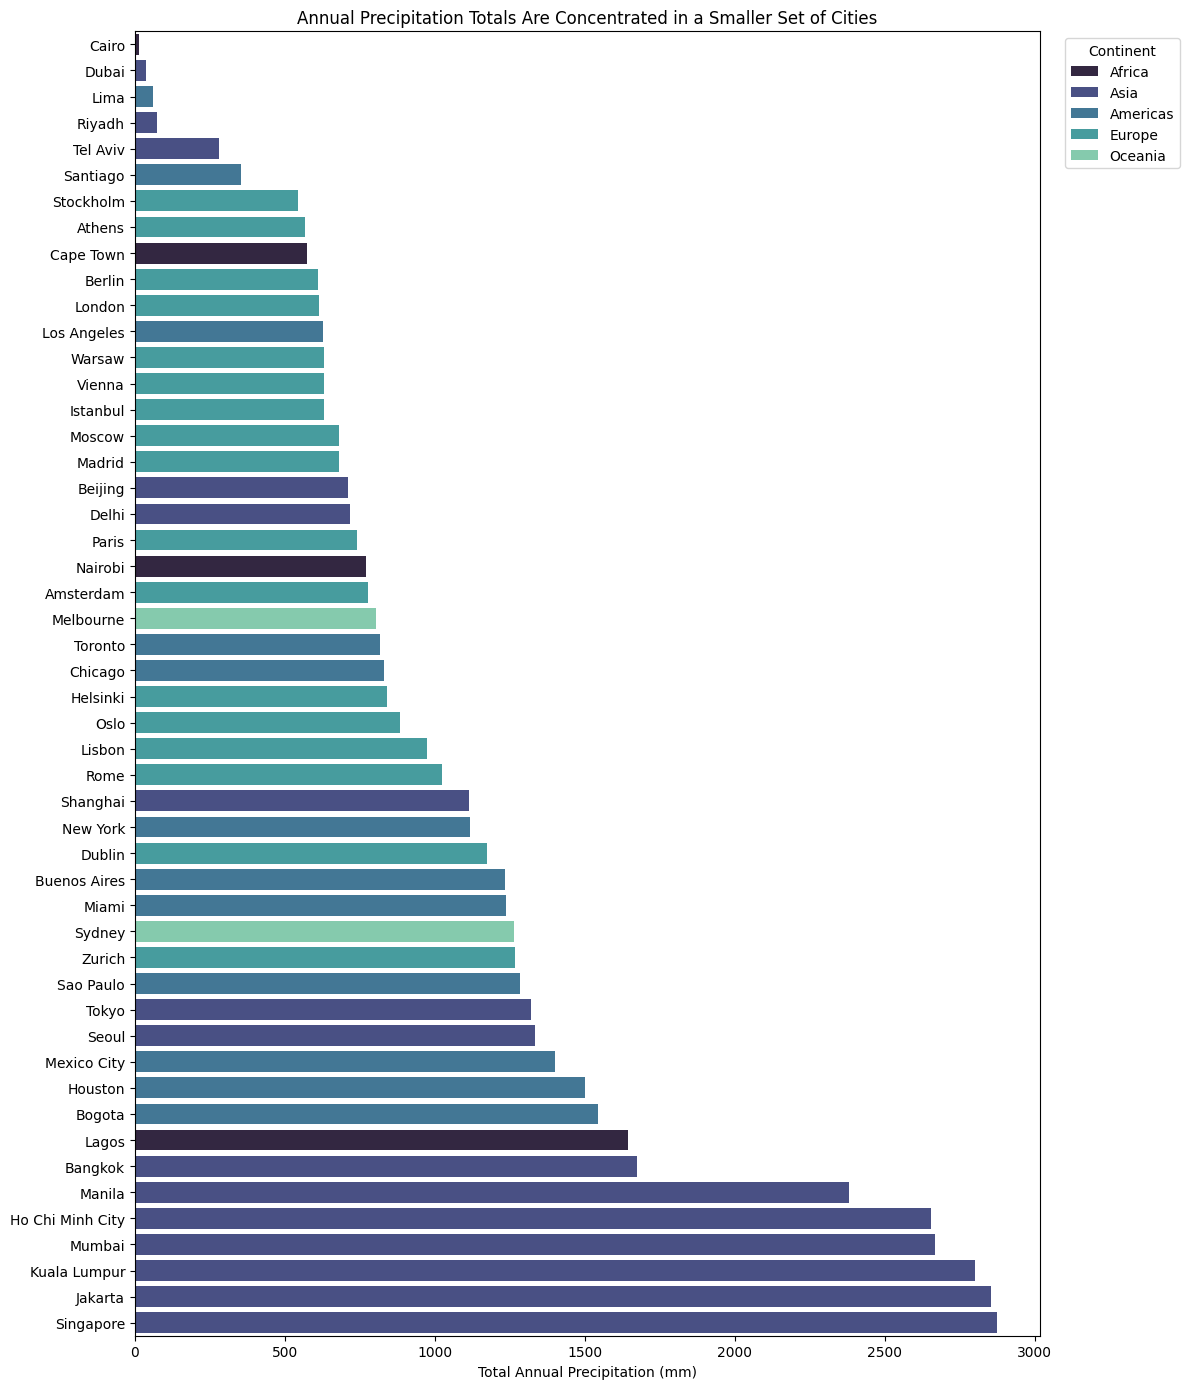

In [14]:
city_rain_rank = city_summary.sort_values("total_precipitation", ascending=True)

plt.figure(figsize=(12, 14))
sns.barplot(data=city_rain_rank, x="total_precipitation", y="city", hue="continent", dodge=False, palette="mako")
plt.title("Annual Precipitation Totals Are Concentrated in a Smaller Set of Cities")
plt.xlabel("Total Annual Precipitation (mm)")
plt.ylabel("")
plt.legend(title="Continent", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Are hot cities all the same, or do humidity and rainfall create different kinds of heat?

So far, the analysis has shown that cities differ in average temperature, seasonality, and rainfall. However, temperature alone still does not fully explain how weather is experienced. A hot city can feel very different depending on whether the air is dry or humid, and whether rainfall is rare or persistent. To explore this, I compare cities using three dimensions at once: annual average temperature, average humidity, and total annual precipitation. This makes it possible to move beyond simple rankings and identify broader weather profiles.

The plot shows that hot cities are far from uniform. On the right side of the chart, several cities combine **high temperatures with high humidity**, and many of these also have **large bubble sizes**, indicating substantial rainfall. This pattern is especially visible among several **Asian cities**, which cluster in the upper-right portion of the chart. These cities represent a **hot-humid-wet** weather profile, where heat is likely intensified by moisture in the air and frequent rainfall. Cities such as **Singapore, Jakarta, Kuala Lumpur, Manila, and Bangkok** are likely part of this group, based on their position and large precipitation totals.

At the same time, some cities with similarly high temperatures appear much lower in humidity and often with smaller bubble sizes. These cities represent a **hot-dry** profile, where high heat is not accompanied by the same level of atmospheric moisture or rainfall. This distinction is important because it shows that two cities can be equally warm on average while offering very different lived weather experiences. Dry heat and humid heat are not interchangeable, and this chart makes that difference visible.

The chart also suggests that cooler cities are not all alike either. Many cities with lower average temperatures still have relatively high humidity, especially in Europe and parts of the Americas. This indicates that humidity is not limited to tropical climates. Some cooler cities may feel damp or wet despite having much lower temperatures than the hot tropical cluster. Meanwhile, cities in the middle temperature range are spread across a wider range of humidity and bubble sizes, suggesting a more mixed set of climate profiles.

Overall, this comparison strengthens the project’s central argument that urban weather is multidimensional. Temperature alone cannot define a city’s climate experience. Instead, the interaction between heat, moisture, and rainfall creates distinct weather identities, including hot-humid-wet, hot-dry, and cooler but humid climates. This richer view helps explain why cities that look similar in one metric may feel very different in practice.

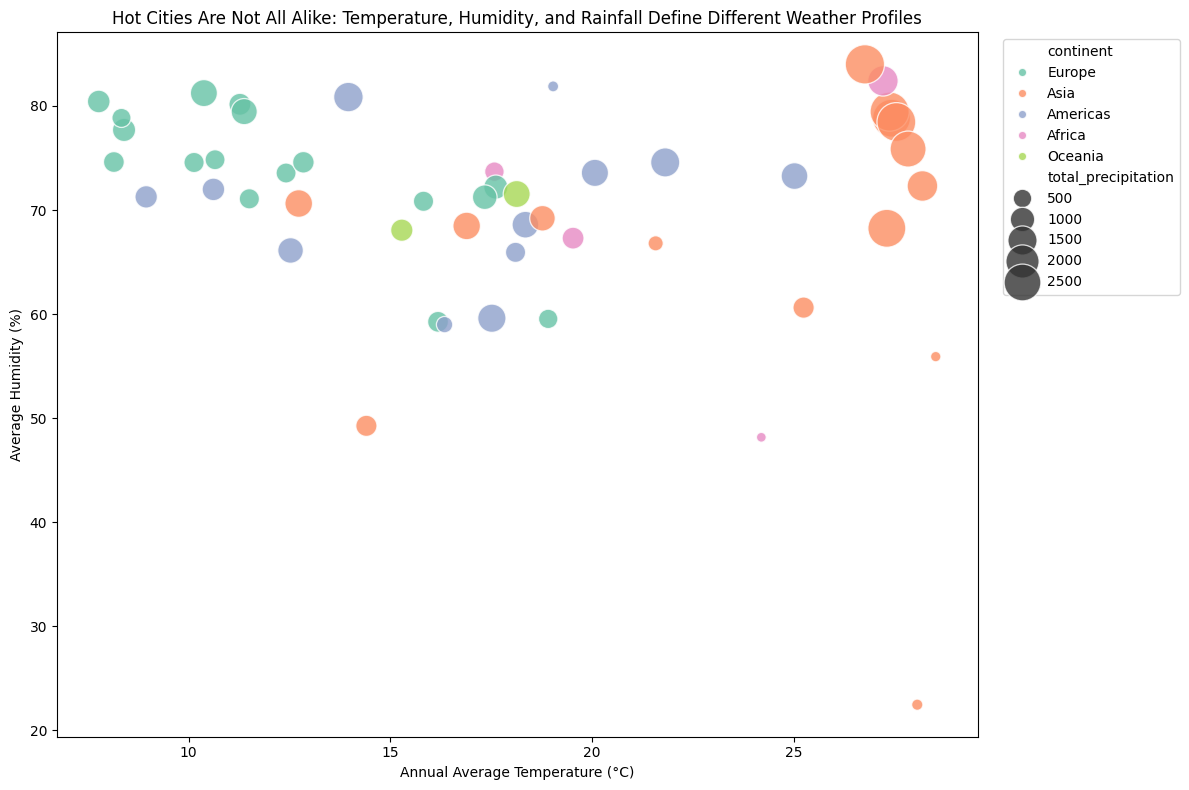

In [15]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=city_summary,
    x="avg_temp_mean",
    y="avg_humidity",
    size="total_precipitation",
    hue="continent",
    sizes=(50, 800),
    alpha=0.8,
    palette="Set2"
)
plt.title("Hot Cities Are Not All Alike: Temperature, Humidity, and Rainfall Define Different Weather Profiles")
plt.xlabel("Annual Average Temperature (°C)")
plt.ylabel("Average Humidity (%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Which cities faced the greatest exposure to extreme weather in 2025?

Average conditions are useful for describing climate, but they do not fully capture how disruptive or intense weather can become. A city may have a moderate annual average while still experiencing many days of extreme heat, heavy rain, or strong wind. To address this, I compare cities based on the number of days that crossed predefined thresholds for extreme heat, heavy rain, and high wind. This helps shift the analysis from typical conditions to weather exposure, which is often more relevant to daily life and urban risk.

The strongest pattern in the chart is the concentration of **extreme heat days** in a small number of already warm cities. **Riyadh** and **Dubai** stand out most clearly, with by far the highest number of extreme heat days, followed by cities such as **Cairo** and **Delhi**. This suggests that some cities do not just have high average temperatures, but experience prolonged periods of very intense heat. These cities represent a form of climate exposure that is persistent rather than occasional, reinforcing the distinction between generally warm cities and cities where heat regularly crosses extreme thresholds.

A different pattern emerges for **heavy rain days**. Cities such as **Kuala Lumpur, Singapore, Jakarta, Ho Chi Minh City, Mumbai, Manila, and Bangkok** show relatively high counts of heavy rain days, which aligns with the earlier finding that many of the wettest cities are concentrated in tropical Asia. This indicates that rainfall exposure is not simply about total annual precipitation, but also about how often intense rain events occur. A city may receive a lot of rain overall, but the number of heavy rain days provides a more practical sense of how frequently residents may face disruptive wet conditions.

In contrast, **high wind days** appear much less common across the dataset. Only a few cities, such as **Dublin**, show a noticeable number of high wind days, while most cities record few or none under the chosen threshold. This suggests that, within this dataset and threshold definition, wind is a less dominant form of extreme exposure than heat or heavy rainfall. Even so, its inclusion is still useful because it shows that not all forms of weather risk are equally distributed.

Overall, this comparison highlights that cities differ not only in their typical weather, but also in the kinds of extremes they are most exposed to. Some cities are defined primarily by repeated extreme heat, others by frequent heavy rain, and only a few by stronger wind exposure. This strengthens the broader story of the project: urban weather profiles are shaped not just by averages, but by the frequency and type of extreme conditions that cities experience throughout the year.

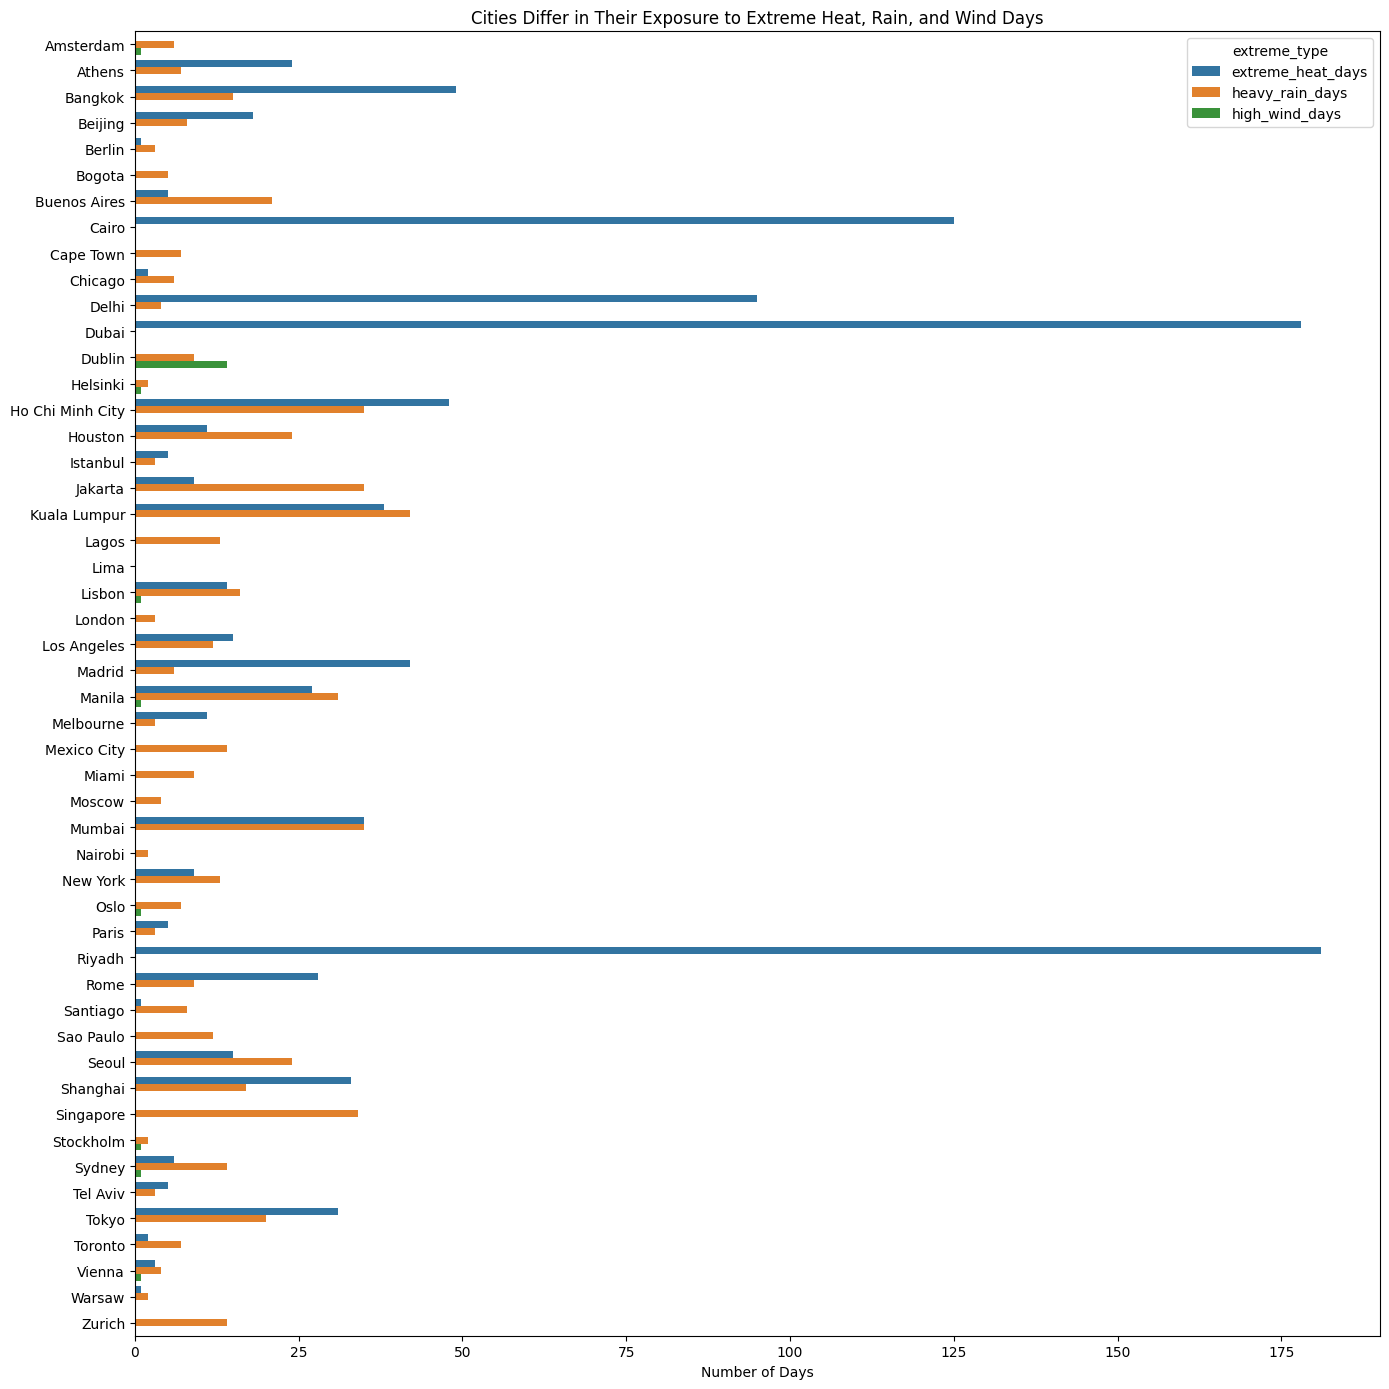

In [16]:
extreme_long = city_summary.melt(
    id_vars=["city", "continent"],
    value_vars=["extreme_heat_days", "heavy_rain_days", "high_wind_days"],
    var_name="extreme_type",
    value_name="days"
)

plt.figure(figsize=(14, 14))
sns.barplot(data=extreme_long, x="days", y="city", hue="extreme_type")
plt.title("Cities Differ in Their Exposure to Extreme Heat, Rain, and Wind Days")
plt.xlabel("Number of Days")
plt.ylabel("")
plt.tight_layout()
plt.show()

### What broader weather profiles emerge when multiple dimensions are considered together?

Up to this point, each section has focused on one part of the story at a time: average temperature, seasonality, rainfall, humidity, or extreme events. However, cities are not defined by a single metric. To understand whether broader weather identities emerge, I bring several variables together in one standardized comparison. By scaling the metrics, each city can be compared relative to the overall dataset average, making it easier to see which cities stand out as unusually hot, variable, wet, humid, windy, or extreme.

Several distinct patterns emerge from this combined view. Cities such as **Singapore, Jakarta, Kuala Lumpur, Manila, Ho Chi Minh City, and Mumbai** show strong positive values for **average temperature**, **precipitation**, and **heavy rain days**, while often showing lower temperature variability. This suggests a clear **hot-humid-rainy tropical profile**, where warmth is persistent, rainfall is high, and weather is relatively stable throughout the year. These cities appear to form one of the most coherent groups in the dataset.

A very different pattern appears for cities such as **Riyadh, Dubai, and Cairo**, which stand out for **high average temperature** and especially high **extreme heat days**, but much lower precipitation. This points to a **hot-dry extreme heat profile**, where cities are not only warm on average but also experience frequent days above the extreme heat threshold. Compared with the tropical cities, these places are defined more by dryness and heat intensity than by humidity and rainfall.

Another group includes cities such as **Beijing, Chicago, Seoul, Toronto, New York, and Moscow**, which tend to show high **temperature variability** rather than consistently high average warmth. These cities represent a **seasonal-variable profile**, where weather changes much more dramatically over the year. Their identity is shaped less by constant heat or rainfall and more by strong seasonal contrast.

There are also cities that appear more moderate or mixed across metrics. For example, some European and Southern Hemisphere cities show values closer to the dataset average on most measures, suggesting more balanced weather profiles without one dominant extreme. Others, such as **Dublin**, stand out more for wind than for heat or rainfall, showing that some cities are distinctive in narrower ways.

Overall, this combined view strengthens the central conclusion of the project: cities do not simply line up from cold to hot or dry to wet. Instead, they form broader weather profiles shaped by the interaction of multiple conditions. Looking at these dimensions together makes it easier to identify tropical, desert, seasonal, and mixed urban climates, which is more informative than any single ranking alone.

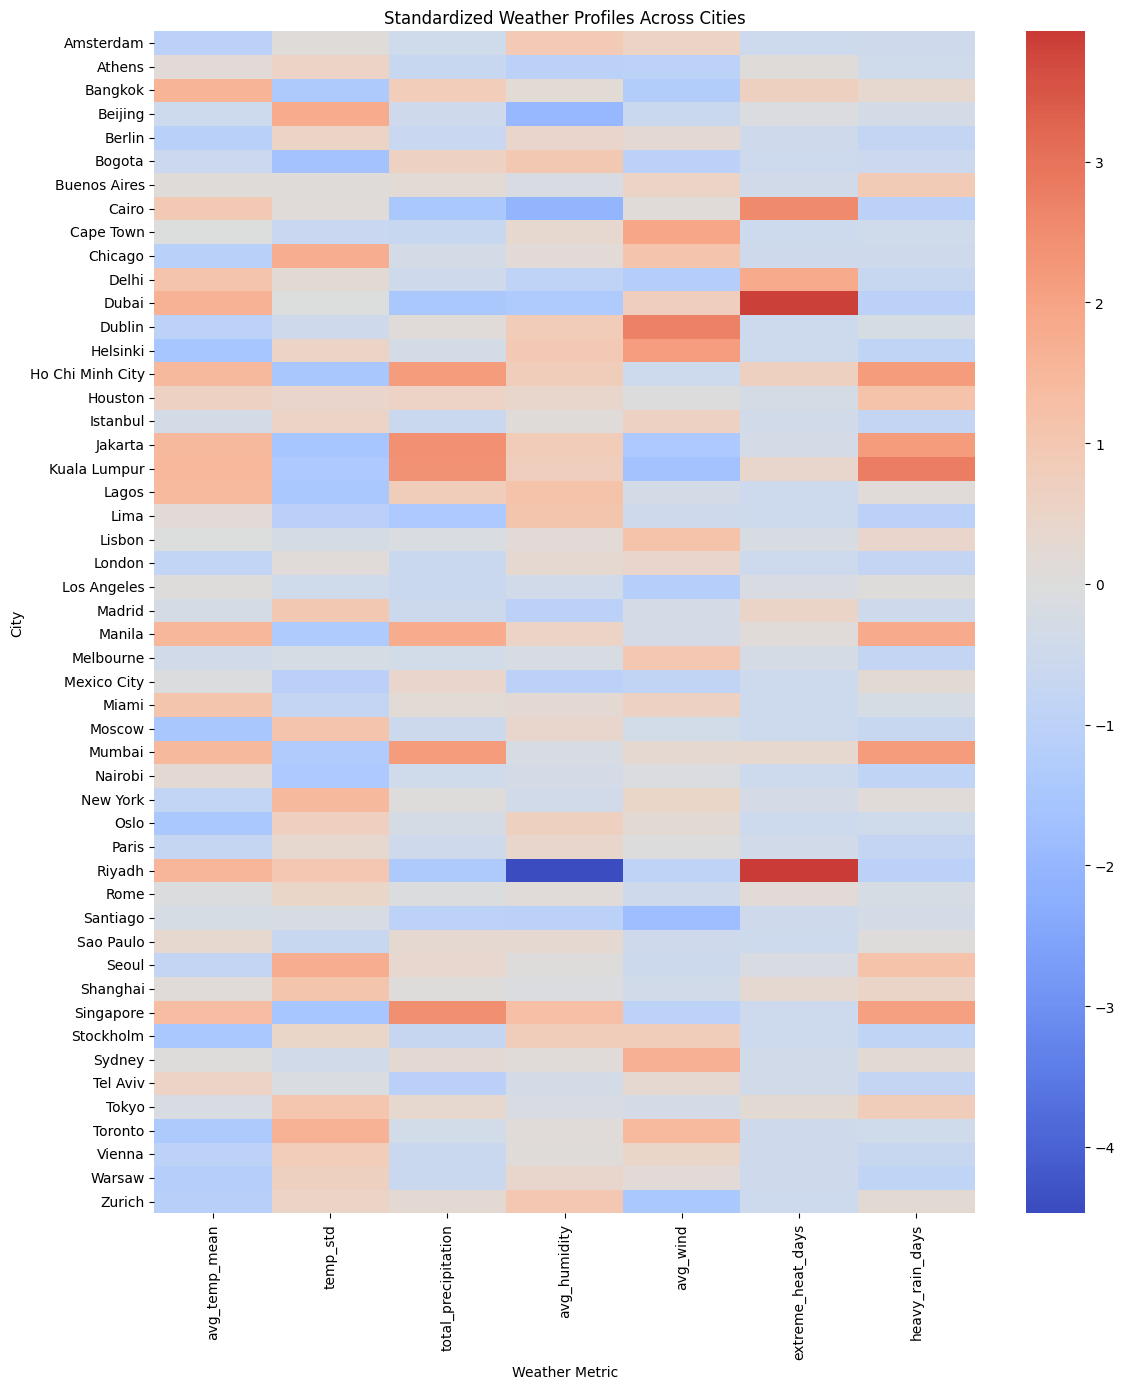

In [17]:
profile_vars = city_summary[
    ["city", "avg_temp_mean", "temp_std", "total_precipitation", "avg_humidity", "avg_wind",
     "extreme_heat_days", "heavy_rain_days"]
].set_index("city")

profile_scaled = (profile_vars - profile_vars.mean()) / profile_vars.std()

plt.figure(figsize=(12, 14))
sns.heatmap(profile_scaled, cmap="coolwarm", center=0)
plt.title("Standardized Weather Profiles Across Cities")
plt.xlabel("Weather Metric")
plt.ylabel("City")
plt.tight_layout()
plt.show()

## How are weather patterns distributed geographically?

The earlier section showed that cities differ in temperature, rainfall, humidity, and exposure to extremes. However, these differences become easier to interpret when placed in geographic context. This section uses map-based analysis to examine how weather patterns are distributed across space and whether the city-level patterns observed earlier align with broader regional and global structure.

To support this part of the analysis, I use country boundary data from Natural Earth and combine it with the weather summaries created earlier. This makes it possible to create choropleth maps showing how average temperature and precipitation vary across countries represented in the dataset, as well as an interactive city-level map for more detailed exploration. Together, these maps extend the story from city comparison to spatial interpretation.

### Projection / CRS considerations

The weather dataset stores city locations using geographic coordinates, specifically **latitude and longitude**, which correspond to the **WGS84 coordinate reference system (EPSG:4326)**. The Natural Earth country boundaries are also commonly provided in a geographic CRS, making them suitable for direct use in global mapping without immediate reprojection.

For this project, a geographic CRS is appropriate because the goal is **global comparison and visualization**, not precise distance or area measurement. However, it is important to note that world maps can visually distort the size and shape of countries, especially at high latitudes, depending on the projection used in the plotting library. As a result, the choropleth maps in this section should be interpreted based on **color patterns and spatial distribution**, rather than the apparent physical area of countries on the map.

### Loading world boundary data

To create country-level maps, I load a global boundary shapefile from the Natural Earth dataset using `geopandas`. This provides the country polygons needed for spatial joins and choropleth mapping.

In [18]:
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


### Inspecting join keys for mapping

Before merging the weather summaries with the world boundary data, I inspect the country identifiers in both tables. This step helps confirm which columns can be used as join keys and whether any country code conversion or cleaning is needed before the spatial join.

In [19]:
display(country_summary.head())
display(world[["ADMIN", "ADM0_A3"]].head())

,country,country_avg_temp,country_total_precipitation,country_avg_humidity,country_extreme_heat_days
0,AE,28.527123,37.1,55.912329,178
1,AR,18.351507,1233.4,68.591781,5
2,AT,11.504932,631.0,71.079452,3
3,AU,16.710685,2068.1,69.801370,17
4,BR,20.074521,1285.3,73.572603,0


,ADMIN,ADM0_A3
0,Fiji,FJI
1,United Republic of Tanzania,TZA
2,Western Sahara,SAH
3,Canada,CAN
4,United States of America,USA


### Converting country codes for the spatial join

The weather data stores countries using **ISO-2 codes**, while the Natural Earth boundary file uses **ISO-3 codes**. To make the merge possible, I convert the weather dataset’s country codes from ISO-2 to ISO-3 format using the `pycountry` library. This ensures that both datasets use a consistent country identifier before joining them for choropleth mapping.

In [20]:
import pycountry

def to_iso3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except:
        return None

country_summary["iso_a3"] = country_summary["country"].apply(to_iso3)

### Joining weather summaries to country boundaries

After aligning the country codes, I merge the country-level weather summary with the world boundary dataset. This creates a geospatial table that combines each country’s polygon geometry with its weather metrics, making it possible to visualize temperature and precipitation patterns on choropleth maps.

To make sure the merge worked correctly, I then verify the matched country codes by comparing `ADM0_A3` from the Natural Earth boundary file with `iso_a3` from the weather summary. This step confirms that the country identifiers align as expected and helps catch any mismatches that could otherwise lead to missing or incorrectly mapped countries in the choropleth visualizations.

In [21]:
world_temp = world.merge(
    country_summary,
    left_on="ADM0_A3",
    right_on="iso_a3",
    how="left"
)

world_temp[world_temp["iso_a3"].notna()][["ADM0_A3", "iso_a3"]]

,ADM0_A3,iso_a3
3,CAN,CAN
4,USA,USA
8,IDN,IDN
9,ARG,ARG
10,CHL,CHL
13,KEN,KEN
18,RUS,RUS
21,NOR,NOR
25,ZAF,ZAF
27,MEX,MEX


## Where are the warmest average conditions located geographically?

After comparing temperature at the city level, the next step is to place those differences on the world map. This helps answer whether the warmest and coolest city patterns observed earlier also follow a broader geographic structure. By mapping average annual temperature at the country level, I can see how warmth is distributed spatially across the countries represented in the dataset.

The map shows a clear geographic pattern. Countries closer to tropical and subtropical regions tend to have higher average annual temperatures, with especially warm values visible across parts of **South Asia**, **Southeast Asia**, the **Middle East**, and parts of **Africa**. Countries such as **Saudi Arabia**, **India**, **Thailand**, **Indonesia**, and the **Philippines** appear among the warmest on the map, which is consistent with the earlier city-level findings for places like Dubai, Bangkok, Jakarta, and Manila.

By contrast, cooler average temperatures are concentrated in **Northern Europe** and higher-latitude parts of the **Northern Hemisphere**, including countries such as **Finland**, **Sweden**, and **Russia**. This reflects the same latitudinal pattern seen earlier in the city rankings, where Helsinki, Stockholm, and Moscow appeared among the coolest cities in the dataset.

Overall, the map reinforces the idea that geography strongly structures average temperature. While city-level analysis highlights individual urban differences, the choropleth shows that these differences are not random: they align closely with broader global climate zones and latitude-based patterns.

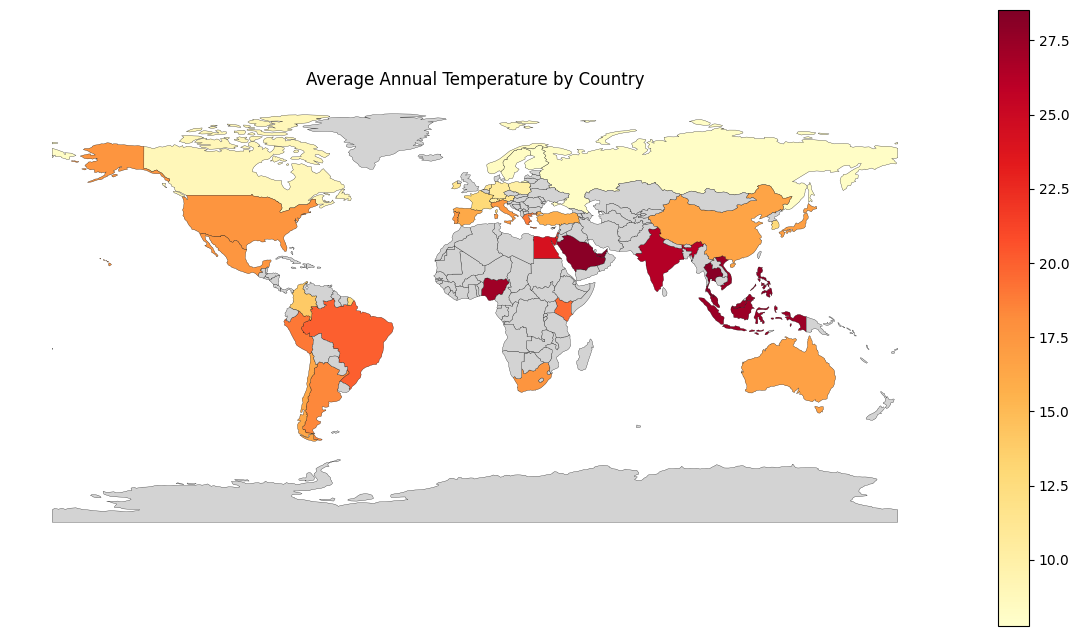

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

world_temp.plot(
    column="country_avg_temp",
    cmap="YlOrRd",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"},
    edgecolor="black",
    linewidth=0.2
)

ax.set_title("Average Annual Temperature by Country")
ax.axis("off")

plt.show()

## Where is rainfall most concentrated across the countries?

While temperature showed a fairly clear latitudinal pattern, precipitation is expected to be more uneven because it depends on a wider range of climate processes, including monsoons, tropical moisture, coastal influence, and regional circulation patterns. To explore this, I map total annual precipitation at the country level. This helps show whether the wettest and driest cities identified earlier are part of broader geographic rainfall patterns.

The map confirms that rainfall is distributed much less evenly than temperature. Some of the highest totals appear in parts of **South Asia** and **Southeast Asia**, especially in countries such as **India**, **Indonesia**, and nearby tropical regions. This aligns with the earlier city-level results, where cities like **Singapore, Jakarta, Kuala Lumpur, Mumbai, Manila, and Ho Chi Minh City** stood out as especially wet. These patterns suggest that strong rainfall is concentrated in monsoon and tropical climate zones rather than spread broadly across all warm regions.

At the same time, several countries associated with dry-climate cities appear much lighter on the map, indicating relatively low annual precipitation. This includes parts of the **Middle East** and other dry regions represented by cities such as **Dubai**, **Riyadh**, and **Cairo**. These countries reinforce the contrast between hot-but-wet and hot-but-dry urban climates.

One result that stands out visually is the very dark shading over the **United States**, which reflects the fact that the country-level value here is based on the weather observations from the cities included in this dataset rather than a full national climate average. Since the dataset contains multiple U.S. cities, the total precipitation shown for the country is effectively the sum of those city-level observations, which makes the mapped value larger than countries represented by only one city. This is an important reminder that the choropleth reflects the structure of this dataset, not complete national weather coverage.

Overall, the map shows that precipitation is concentrated in specific regional clusters, especially across tropical and monsoon-influenced parts of Asia, while dry conditions remain visible in the Middle East and some other arid regions. Compared with temperature, rainfall follows a less uniform global pattern, which helps explain why wetness is such a distinctive part of certain cities’ weather profiles.

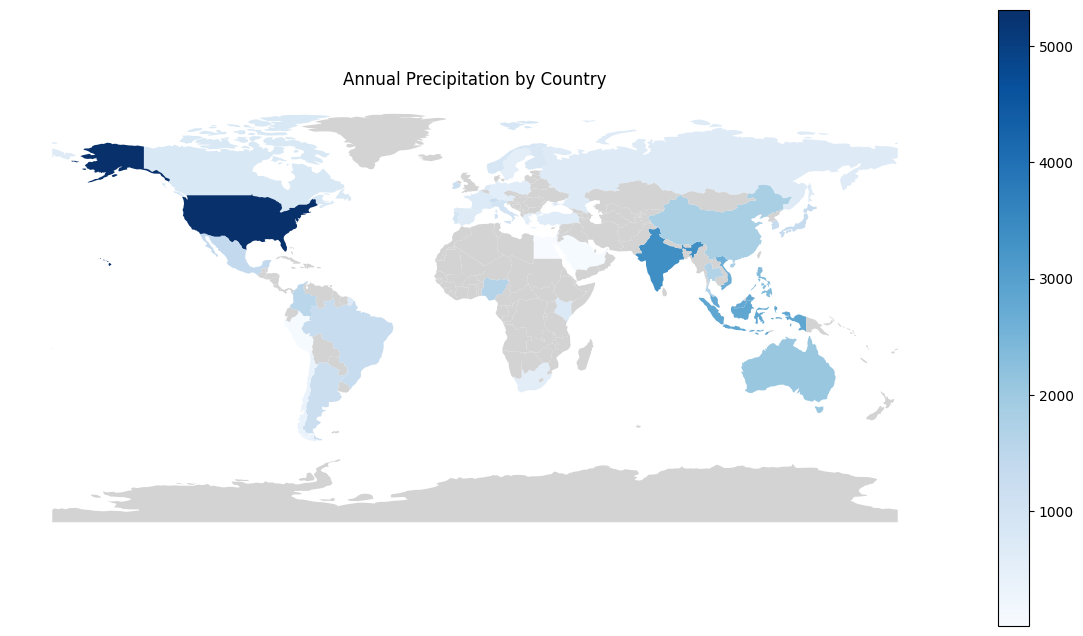

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
world_temp.plot(column="country_total_precipitation", cmap="Blues", legend=True, ax=ax, missing_kwds={"color": "lightgrey"})
ax.set_title("Annual Precipitation by Country")
ax.axis("off")
plt.show()

## How do temperature, rainfall, and extremes come together at the city level?
While the choropleth maps provide a useful country-level overview, they do not show the full variation between individual cities. To bring the analysis back to the city level, I create an interactive map using each city’s coordinates and annual weather summary. In this map, color represents average annual temperature, marker size represents total annual precipitation, and the hover information includes additional details such as humidity and counts of extreme heat and heavy rain days. This allows multiple dimensions of each city’s weather profile to be explored in one place.

The map makes several patterns easy to spot. Many cities in **South and Southeast Asia** appear as both **warm-colored and large markers**, indicating that they combine high temperatures with high rainfall. This supports the earlier conclusion that cities such as **Singapore, Jakarta, Kuala Lumpur, Manila, and Bangkok** belong to a hot-humid-rainy weather profile. In contrast, cities in the **Middle East** such as **Dubai** and **Riyadh** appear warm in color but much smaller in size, showing that high temperature does not necessarily come with high precipitation.

The map also shows a visible cluster of cooler cities across **Europe**, where markers tend to be darker or cooler in color and generally smaller to moderate in size. This aligns with the earlier findings that many European cities have lower annual average temperatures and more moderate rainfall totals. Cities in the **Americas**, **Africa**, and **Oceania** appear more mixed, which reflects the broader diversity already seen in the earlier city-level comparisons.

A key advantage of this map is that it allows for direct exploration rather than only fixed interpretation. By hovering over each city, the reader can compare places that may share one feature, such as temperature, but differ in humidity, rainfall, or exposure to extremes. Overall, this interactive map serves as a useful synthesis of the project’s main findings, bringing together geography, climate, and city-level weather experience in a single exploratory view.

In [35]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

city_coords = weather.groupby("city", as_index=False)[["latitude", "longitude"]].first()

city_map_data = city_summary.merge(
    city_coords,
    on="city",
    how="left"
)

city_map_data["latitude"] = pd.to_numeric(city_map_data["latitude"], errors="coerce")
city_map_data["longitude"] = pd.to_numeric(city_map_data["longitude"], errors="coerce")

city_map_data = city_map_data.dropna(subset=["latitude", "longitude"])

fig = px.scatter_map(
    city_map_data,
    lat="latitude",
    lon="longitude",
    color="avg_temp_mean",
    size="total_precipitation",
    hover_name="city",
    hover_data={
        "country": True,
        "avg_temp_mean": ":.1f",
        "avg_humidity": ":.1f",
        "extreme_heat_days": True,
        "heavy_rain_days": True,
        "latitude": False,
        "longitude": False
    },
    color_continuous_scale="Turbo",
    size_max=25,
    zoom=1,
    title="Interactive Map of City Weather Profiles"
)

fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

fig.show()

## How do weather patterns change over time across continents?
To add an interactive and exploratory layer to the project, I create a mini-dashboard view that tracks daily average weather conditions across continents over time. This supports the broader goal of moving from static comparisons to a more flexible interface where readers can inspect temporal patterns dynamically. By grouping the data by **continent** and **date**, this view summarizes how weather changes across large regions throughout 2025, while the function structure allows different metrics to be explored beyond temperature alone.

When the dashboard is applied to **daily mean temperature**, several broad patterns become visible. **Asia** remains the warmest continent for much of the year, with temperatures staying relatively high and peaking around the middle of the year. **Africa** also stays consistently warm, though with less dramatic seasonal movement than Europe. In contrast, **Europe** shows the strongest seasonal cycle, beginning the year at much lower temperatures, rising sharply into summer, and then falling again toward winter. This reflects the more pronounced seasonality already observed in many European cities.

The **Americas** and **Oceania** show intermediate but distinct patterns. The Americas display moderate seasonality, with a rise in the middle of the year and a decline afterward, while Oceania follows a different cycle because of the Southern Hemisphere seasonal pattern. Its temperatures are relatively higher at the beginning and end of the year and lower around the middle, which provides a useful contrast to the Northern Hemisphere continents. This reversal helps reinforce the importance of geographic location in shaping annual weather rhythms.

Overall, this interactive time-based view strengthens the project by showing that weather differences are not only spatial, but also temporal. It gives the audience a way to compare how entire continents warm and cool across the year, while also serving as a flexible building block for a broader dashboard where other metrics such as precipitation, humidity, or wind can be explored in the same format.

In [36]:
pio.renderers.default = "notebook_connected"

def continent_timeseries(metric="temp_mean_c"):
    
    continent_df = weather.groupby(
        ["continent", "date"], 
        as_index=False
    )[metric].mean()
    
    fig = px.line(
        continent_df,
        x="date",
        y=metric,
        color="continent",
        title=f"{metric} over time by continent",
        labels={
            "date": "Date",
            metric: metric,
            "continent": "Continent"
        }
    )
    
    fig.show()

continent_timeseries("temp_mean_c")

## Can weather patterns help explain extreme heat, and how can they be translated into human-readable language?

The earlier sections of this project focused on descriptive analysis, showing how cities differ in average conditions, seasonality, rainfall, humidity, and exposure to extremes. This section extends the analysis in two ways. First, it uses a simple machine learning model to test whether recurring weather and geographic features can help predict whether a given day is an **extreme heat day**. Second, it adds an NLP-style visualization that translates structured weather patterns into descriptive language, making the results more accessible to a non-expert audience.

The machine learning component is designed to move from description to prediction. Instead of only showing where extreme heat occurs, it asks whether the combination of temperature, precipitation, humidity, wind, location, and season can help identify those days systematically. To keep the model interpretable and aligned with the project’s storytelling goals, the target variable is defined as a binary indicator for extreme heat, and the results will be evaluated using feature importance, a confusion matrix, and an ROC curve.

The NLP component complements this by turning numeric weather conditions into simplified descriptive text, such as “hot,” “humid,” or “rainy,” and then visualizing those patterns through a word cloud. Together, these two approaches allow the project to show not only what the data looks like, but also how weather patterns can be both predicted and described.

### Defining the prediction task

To build the machine learning model, I first create a modeling dataset and define the input features and target variable. The selected features include weather measurements, geographic coordinates, time information, and city identity, while the target is whether a given observation is classified as an `extreme_heat_day`. This setup allows the model to learn which combinations of conditions are most associated with extreme heat.

In [26]:
ml_df = weather.copy()

features = [
    "temp_mean_c",
    "temp_min_c",
    "humidity_pct",
    "precipitation_mm",
    "rain_mm",
    "wind_max_kmh",
    "latitude",
    "longitude",
    "month",
    "city"
]

target = "extreme_heat_day"

X = ml_df[features]
y = ml_df[target]

### Splitting the data for training and evaluation

To evaluate the model fairly, the data is split into training and testing sets. I use a stratified split so that the proportion of extreme heat days remains similar

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

### Preparing the features and training the model

Before fitting the model, I separate the inputs into **categorical** and **numeric** features so they can be processed appropriately. The `city` variable is one-hot encoded, while the numeric weather, location, and time variables are passed through directly. I then use a **Random Forest classifier** because it can capture nonlinear relationships, handle mixed feature types well, and provide feature importance scores for interpretation. The model is trained within a pipeline so that preprocessing and prediction are handled together in a clean and reproducible workflow.

In [28]:
categorical_features = ["city"]
numeric_features = [
    "temp_mean_c", "temp_min_c", "humidity_pct", "precipitation_mm",
    "rain_mm", "wind_max_kmh", "latitude", "longitude", "month"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    class_weight="balanced"
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### Evaluating how well the model identifies extreme heat days

After training the model, I generate predictions on the test set and evaluate its performance using a classification report and ROC AUC score. These metrics help assess not only overall accuracy, but also how well the model identifies the minority class of interest: extreme heat days.

The results indicate that the model performs very strongly overall. It achieves an **accuracy of 0.99** and an **ROC AUC of approximately 0.997**, suggesting excellent separation between extreme heat days and non-extreme days. For the non-extreme class (`0`), both precision and recall are extremely high at around **0.99 to 1.00**, which shows that the model is highly reliable in identifying typical days.

More importantly, the model also performs well on the extreme heat class (`1`), which is the main focus of this prediction task. It achieves a **precision of 0.94**, meaning that most days predicted as extreme heat are truly extreme, and a **recall of 0.84**, meaning that it successfully captures most actual extreme heat days. The **F1-score of 0.89** for the positive class shows a strong balance between precision and recall.

Overall, these results suggest that extreme heat days are not random or difficult to distinguish in this dataset. Instead, they are strongly associated with recurring weather, geographic, and seasonal patterns that the model is able to learn effectively.

In [29]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3436
           1       0.94      0.84      0.89       214

    accuracy                           0.99      3650
   macro avg       0.97      0.92      0.94      3650
weighted avg       0.99      0.99      0.99      3650

ROC AUC: 0.9974962736500821


## Where does the model make correct predictions, and where does it make mistakes?

To better understand the model’s performance, I use a confusion matrix to break the predictions into correct and incorrect classifications. This is especially useful because the project is focused on identifying **extreme heat days**, so it is important to know not just how accurate the model is overall, but whether it is missing too many extreme cases or incorrectly flagging too many normal days.

The confusion matrix shows that the model performs very well on both classes. It correctly identifies **3425 non-extreme days** and **180 extreme heat days**. The number of **false positives** is very small, with only **11 normal days** incorrectly predicted as extreme. This supports the high precision seen earlier, meaning that when the model predicts an extreme heat day, it is usually correct.

There are also **34 false negatives**, where actual extreme heat days were missed and classified as non-extreme. While this is still a relatively small number, it is more important from an analytical perspective because these are the days the model failed to detect. This explains why recall for the extreme heat class is slightly lower than precision. Even so, the model still captures the large majority of extreme heat days successfully.

Overall, the confusion matrix confirms that the model is highly effective at distinguishing extreme heat from normal conditions. It also shows that the main remaining challenge is not overpredicting extremes, but missing a small number of true extreme heat days.

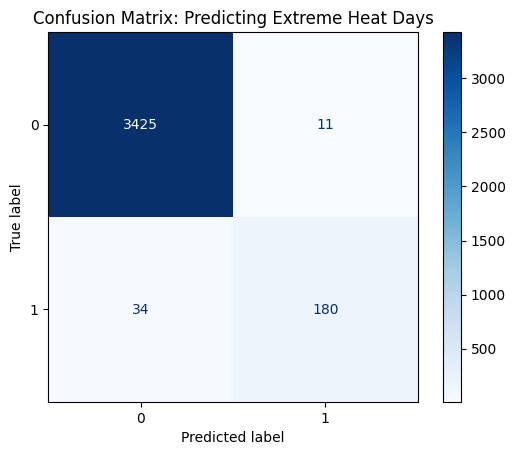

In [30]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Predicting Extreme Heat Days")
plt.show()

## How well does the model separate extreme heat days from non-extreme days across different thresholds?

While the confusion matrix evaluates performance at one classification threshold, the ROC curve provides a broader view by showing how the model performs across all possible thresholds. This is useful because it reveals whether the model can consistently distinguish extreme heat days from non-extreme days, regardless of where the decision cutoff is placed.

The ROC curve rises very sharply toward the top-left corner of the plot, which indicates strong classification performance. The model achieves an **AUC of 0.997**, which is extremely high and suggests that it has excellent ability to separate the two classes. In practical terms, this means the model almost always assigns higher predicted probabilities to true extreme heat days than to normal days.

The curve also sits far above the diagonal reference line, which represents random guessing. This confirms that the model is learning meaningful structure from the weather, location, and seasonal features rather than making predictions by chance.

Overall, the ROC curve reinforces the earlier evaluation results: extreme heat days are highly predictable in this dataset, and the model performs strongly not just at one decision threshold, but across a wide range of thresholds.

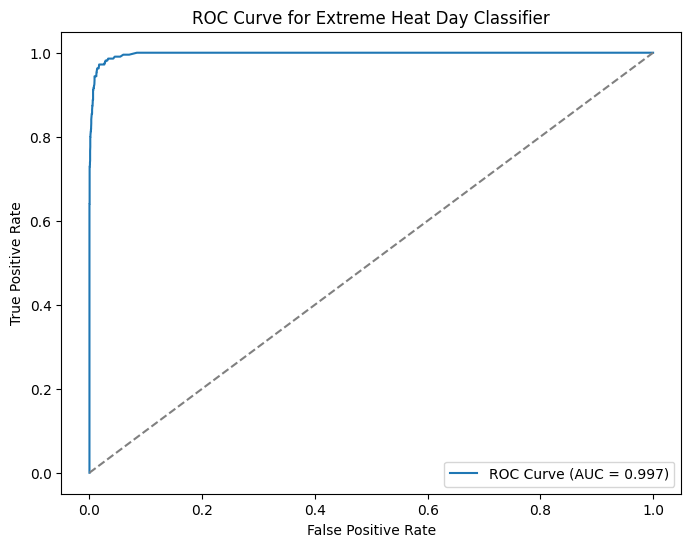

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Extreme Heat Day Classifier")
plt.legend()
plt.show()

## Which factors matter most for predicting extreme heat days?

To interpret the model more meaningfully, I examine the feature importance scores from the Random Forest classifier. This helps identify which variables contribute most to predicting whether a day is classified as an extreme heat day. Rather than treating the model as a black box, this step connects the prediction results back to the broader weather story developed earlier in the project.

The feature importance plot shows that **`temp_mean_c`** is by far the strongest predictor, followed by **`temp_min_c`** and **`humidity_pct`**. This makes intuitive sense: days with higher average and minimum temperatures are much more likely to cross the extreme heat threshold, and humidity also plays an important role in distinguishing the conditions associated with very hot days. These results reinforce the earlier descriptive findings that heat is not just about one temperature measure, but about a broader combination of atmospheric conditions.

Location and seasonal context also matter. **Longitude**, **latitude**, and **month** all appear among the more important features, suggesting that geography and time of year help the model identify where and when extreme heat is more likely to occur. This aligns with the earlier visual analysis showing that extreme heat is concentrated in certain regions and seasons rather than being evenly distributed across the dataset.

Precipitation, rainfall, and wind contribute less strongly than temperature and humidity, but they still appear among the top features, indicating that they add some predictive value. In addition, a few city-specific indicators such as **Riyadh**, **Dubai**, **Cairo**, **Miami**, and **Delhi** appear in the top features, which suggests that certain cities have distinctive weather patterns strongly associated with extreme heat.

Overall, the feature importance results support the broader narrative of the project: extreme heat is shaped most strongly by core temperature conditions, but geography, seasonality, humidity, and city context also play meaningful roles.

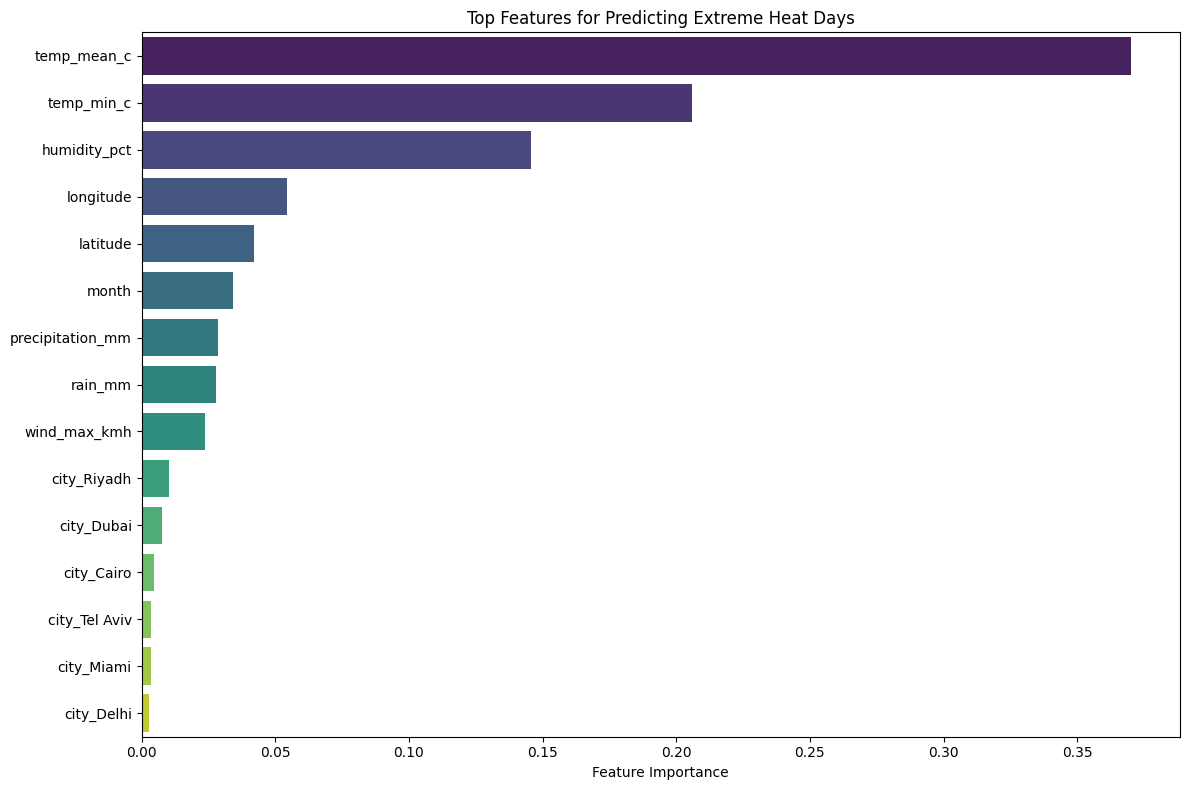

In [32]:
ohe = pipeline.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = list(encoded_cat_names) + numeric_features

importances = pipeline.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(data=feat_imp, x="importance", y="feature", hue="feature", palette="viridis")
plt.title("Top Features for Predicting Extreme Heat Days")
plt.xlabel("Feature Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Translating weather measurements into descriptive language

Because the dataset is structured numeric data rather than natural language text, I create a derived text field to support the NLP-style part of the project. For each city-day observation, I convert the weather measurements into a short descriptive phrase based on thresholds for temperature, humidity, rainfall, wind, and daily variability. This produces labels such as **“very_hot humid heavy_rain”** or **“mild dry_day calm”**.

The purpose of this step is to make the weather data more human-readable and to create a text corpus that can be used for a word cloud or other NLP-style visualization. By translating numeric conditions into descriptive words, the analysis becomes easier to communicate to a non-expert audience while still remaining grounded in the original data.

In [33]:
def describe_weather(row):
    words = []
    
    # Temperature description
    if row["temp_max_c"] >= 35:
        words.append("very_hot")
    elif row["temp_mean_c"] >= 28:
        words.append("hot")
    elif row["temp_mean_c"] >= 20:
        words.append("warm")
    elif row["temp_mean_c"] >= 10:
        words.append("mild")
    else:
        words.append("cool")
    
    # Humidity description
    if row["humidity_pct"] >= 80:
        words.append("humid")
    elif row["humidity_pct"] <= 40:
        words.append("dry")
    
    # Rain description
    if row["precipitation_mm"] >= 20:
        words.append("heavy_rain")
    elif row["precipitation_mm"] > 0:
        words.append("rainy")
    else:
        words.append("dry_day")
    
    # Wind description
    if row["wind_max_kmh"] >= 40:
        words.append("windy")
    elif row["wind_max_kmh"] <= 15:
        words.append("calm")
    
    # Temperature range
    if row["temp_range_c"] >= 15:
        words.append("high_variability")
    elif row["temp_range_c"] <= 5:
        words.append("stable")
    
    return " ".join(words)

weather["weather_text"] = weather.apply(describe_weather, axis=1)

weather[["city", "date", "weather_text"]].head(10)

,city,date,weather_text
0,New York,2025-01-01,cool humid rainy
1,New York,2025-01-02,cool dry_day
2,New York,2025-01-03,cool dry_day
3,New York,2025-01-04,cool dry_day stable
4,New York,2025-01-05,cool dry_day stable
5,New York,2025-01-06,cool rainy stable
6,New York,2025-01-07,cool dry_day
7,New York,2025-01-08,cool dry_day stable
8,New York,2025-01-09,cool dry_day
9,New York,2025-01-10,cool dry_day


## What words best describe weather patterns across different continents?

To complement the machine learning results with a more human-readable summary, I generate continent-level word clouds from the derived `weather_text` field. Each word cloud is built from the descriptive labels assigned to daily weather observations, so the size of each word reflects how often that type of condition appears within a continent. This provides an NLP-style visualization that helps translate structured weather data into a simpler descriptive vocabulary.

The word clouds reveal clear regional differences in weather experience. In **Asia**, large words such as **“rainy,” “humid,” “warm,”** and **“calm”** stand out, which is consistent with the earlier findings that many Asian cities are hot, humid, and precipitation-heavy. In **Europe**, more prominent terms such as **“cool,” “mild,” “rainy,”** and **“humid”** reflect a generally cooler and more temperate climate profile. The **Americas** show a more mixed vocabulary, combining terms like **“mild,” “humid,” “rainy,”** and **“dry_day,”** which suggests greater diversity across the cities included from North and South America.

In **Africa**, the prominence of words such as **“dry_day,” “calm,” “humid,”** and **“mild”** suggests a mix of dry and warm conditions, though the continent’s smaller city sample should be kept in mind when interpreting the results. **Oceania** appears to emphasize **“mild,” “rainy,” “humid,”** and **“stable,”** which fits the more moderate climate patterns seen earlier for Sydney and Melbourne.

Overall, these word clouds provide a useful narrative complement to the numeric analysis. They do not replace the quantitative results, but they help summarize each region’s dominant weather character in a way that is intuitive and accessible. This makes the final stage of the project not only predictive and analytical, but also more interpretable for non-expert readers.

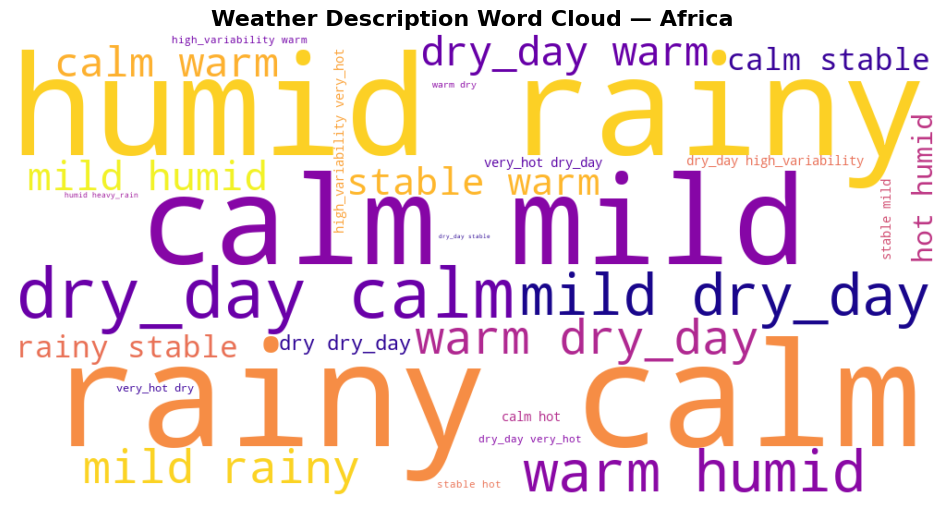

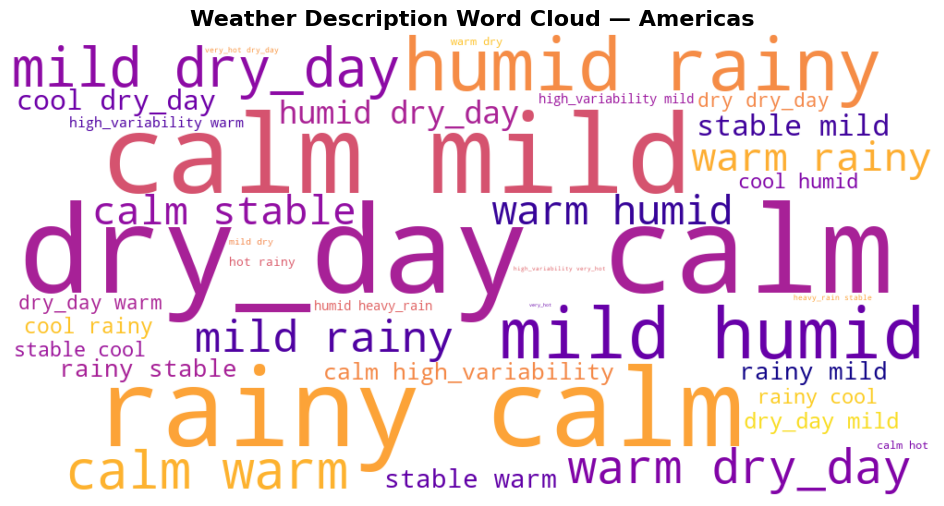

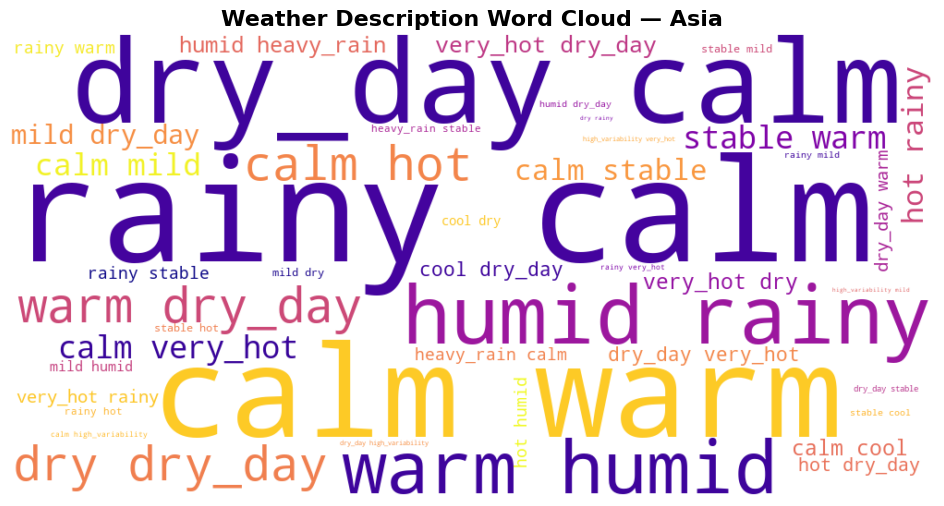

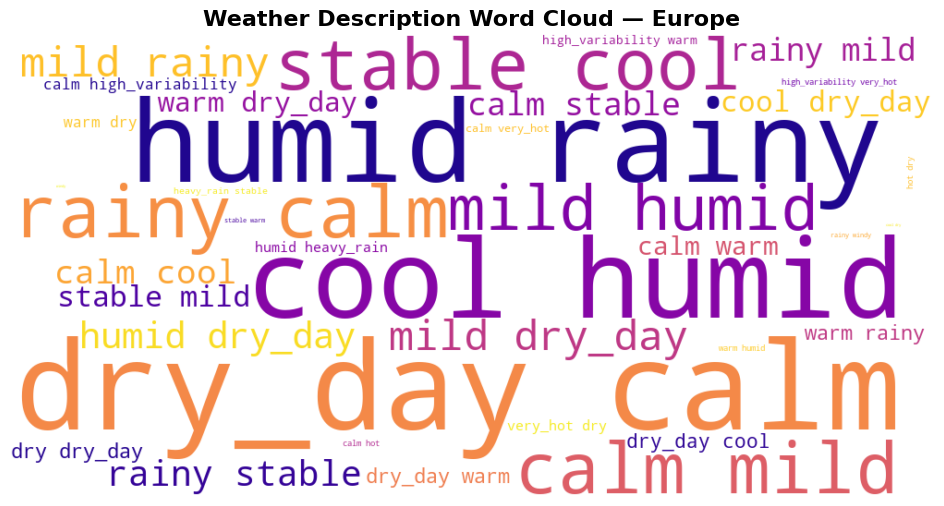

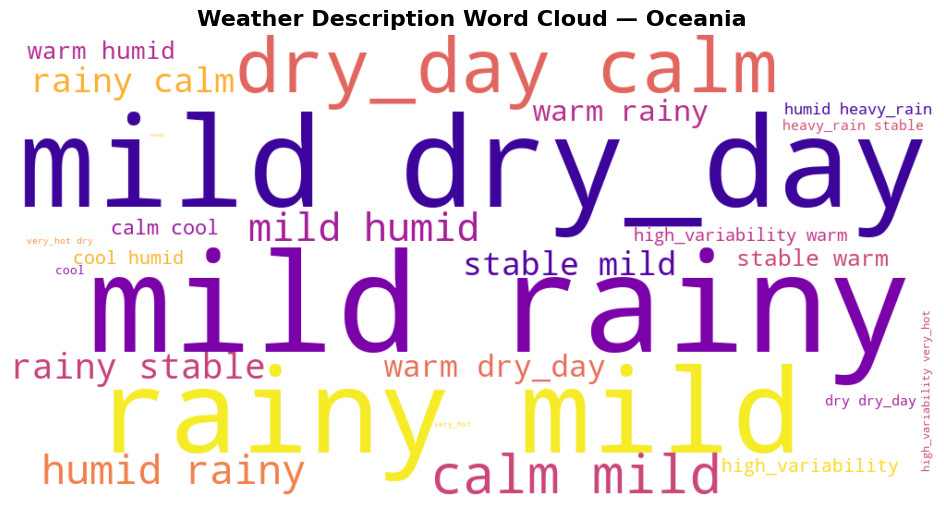

In [34]:
from wordcloud import WordCloud

continents = weather["continent"].dropna().unique()

for cont in sorted(continents):
    text = " ".join(weather.loc[weather["continent"] == cont, "weather_text"].dropna())
    
    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        colormap="plasma",
        max_words=60
    ).generate(text)
    
    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Weather Description Word Cloud — {cont}", fontsize=16, weight="bold")
    plt.show()

## Discussion and Conclusion

This project set out to understand how weather patterns differed across 50 major global cities in 2025, and the analysis shows clearly that urban climate cannot be reduced to a simple ranking of hot and cold places. Across the visualizations, a broader pattern emerged: cities differ not only in their average temperatures, but also in their seasonality, humidity, rainfall concentration, and exposure to extreme weather. Together, these dimensions create distinct weather profiles that shape how climate is experienced in everyday urban life.

One of the clearest insights from the analysis is that **average temperature alone is not enough**. Cities with similar annual mean temperatures can feel very different depending on how much they fluctuate over time. For example, tropical cities such as **Singapore** remain warm and relatively stable throughout the year, while cities such as **Moscow** and **New York** show much stronger seasonal swings. This means that stability and variability are essential parts of climate experience, not just secondary details.

A second major takeaway is that **hot cities are not all the same**. The analysis of humidity and precipitation showed that some cities are hot and dry, such as **Dubai** and **Riyadh**, while others are hot, humid, and rain-heavy, such as **Jakarta**, **Kuala Lumpur**, and **Manila**. This distinction matters because dry heat and humid heat are experienced differently, and rainfall adds another layer to how livable or disruptive weather may feel. In this sense, temperature, humidity, and rainfall work together to create more meaningful weather identities than any one variable alone.

The analysis of extreme weather further strengthened this point. Some cities stood out for repeated **extreme heat days**, others for **heavy rain days**, and only a few for stronger **wind exposure**. This suggests that climate risk is not uniform across cities. Instead, different places face different forms of weather stress, which has practical implications for how urban environments are experienced and potentially managed.

The map-based analysis added an important geographic perspective. The choropleths showed that average temperature follows a fairly clear latitudinal pattern, while precipitation is more regionally concentrated, especially in tropical and monsoon-influenced parts of Asia. The interactive city map then brought these dimensions together and made it easier to compare how temperature, rainfall, and extremes combine in specific locations. This helped reinforce the idea that weather patterns are spatially structured rather than random.

The machine learning section showed that **extreme heat days are highly predictable** in this dataset. Features such as mean temperature, minimum temperature, humidity, location, and month played especially important roles, and the model achieved very strong performance overall. This suggests that extreme heat is not simply a rare irregular event, but one that is strongly associated with recurring climatic and geographic patterns. The NLP-style word clouds then added a final interpretive layer by translating numeric weather conditions into descriptive terms, making the dataset more readable for a non-expert audience.

### Key Takeaways

- Urban weather is **multidimensional**, not defined by temperature alone.
- Cities with similar annual averages can still differ greatly in **seasonality and variability**.
- Warm cities split into different profiles, especially **hot-dry** and **hot-humid-wet** climates.
- Extreme weather exposure varies by city, with different places facing different dominant risks.
- Geography helps explain these patterns, especially through **latitude and regional climate systems**.
- Predictive modeling confirms that extreme heat is strongly tied to recurring weather and location-based signals.

### Reflection

One of the most interesting parts of this project was seeing how a familiar topic like weather could become much richer when viewed through multiple analytical lenses. At first, it might seem that comparing cities by average temperature would be enough, but the deeper analysis showed that weather experience is shaped by a combination of factors that interact in meaningful ways. The project also reinforced how important storytelling is in data visualization: the strongest insights came not from isolated charts, but from arranging the visuals in a sequence that gradually built a more complete explanation of urban climate differences.

Another useful takeaway from this project was the value of combining different methods in one coherent story. Static charts helped establish the main comparisons, maps added geographic context, the interactive views encouraged exploration, and the ML/NLP section extended the analysis into prediction and interpretation. Together, these components made the final project feel more complete and closer to a real end-to-end data storytelling workflow.

### Limitations

This project also has several limitations that should be kept in mind. First, the dataset covers only **one year (2025)**, so the analysis reflects weather during that year rather than long-term climate normals. A colder or warmer than usual year could affect the results. Second, the dataset includes only **50 cities**, which provides global breadth but not full geographic coverage. Some regions are represented more heavily than others, and the selected cities may not capture all climate variation within a continent.

Third, the data is at the **city level**, which means it cannot reflect variation within large metropolitan areas. Weather can differ across neighborhoods, elevations, and coastal versus inland zones, but those local differences are not visible here. Fourth, some thresholds used in the project, such as the definitions of extreme heat, heavy rain, and high wind days, are analytical choices rather than universal standards. Different thresholds might slightly change the results.

There are also limitations in the map-based analysis. The country-level choropleths are based only on the cities represented in the dataset, not full national weather coverage, so they should be interpreted as summaries of the sampled cities rather than complete country climate profiles. Finally, the machine learning model is intended as an explanatory tool rather than a real forecasting system. Its strong performance reflects patterns within this dataset, but it is not designed for operational prediction beyond the scope of the project.

### Final Conclusion

Overall, this project shows that weather across global cities in 2025 is best understood as a set of distinct urban climate experiences rather than a single global spectrum from cold to hot. Cities differ in how warm they are, how stable their temperatures remain, how much rain they receive, how humid conditions feel, and how often extreme days occur. By combining data wrangling, storytelling, visualization, mapping, interactivity, machine learning, and NLP-style interpretation, the analysis turns daily weather records into a broader story about how geography shapes life in cities around the world.